# Laboratorio 6 — Hito 2: análisis exploratorio y red bipartita

**Universidad del Valle de Guatemala — CC3084 Data Science — Semestre II, 2026**

Conserva íntegro el hito 1 y añade las actividades 3 y 4.

## tl;dr

- Este notebook repite el hito 1 completo y sobre él construye el análisis exploratorio y la red bipartita autor–video.
- La participación está muy concentrada: un solo video reúne el 39.7 % de los comentarios y un solo canal el 63.1 % (Gini de comentarios por video con cobertura: 0.66).
- Sólo 9 de 332 autores comentan en más de un video y 4 cruzan canales distintos.
- La red completa contiene 625 nodos y 343 aristas cuyo peso suma 406, es decir, el total de comentarios.
- Los 274 videos sin comentarios se conservan en la red como falta de cobertura, no como aislamiento social demostrado.

## 0. Preparación del entorno

In [1]:
from __future__ import annotations

import json
import re
import unicodedata
import warnings
from urllib.parse import unquote
from collections import Counter
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.lines import Line2D
from scipy import stats

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 90)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 200,
    "savefig.bbox": "tight",
    "font.size": 10,
    "axes.titleweight": "bold",
})

AZUL, NARANJA, VERDE, ROJO, MORADO, GRIS = (
    "#2b6cb0", "#dd6b20", "#2f855a", "#c53030", "#6b46c1", "#718096",
)
PALETA = [AZUL, NARANJA, VERDE, ROJO, MORADO, "#00838f", "#b7791f", "#4a5568"]


def encontrar_raiz(inicio: Path) -> Path:
    """Localiza la raíz del repositorio buscando los CSV originales."""
    for candidato in (inicio, *inicio.parents):
        if (candidato / "youtube_videos.csv").exists() and (candidato / "youtube_comments.csv").exists():
            return candidato
    raise FileNotFoundError("No se encontraron youtube_videos.csv y youtube_comments.csv.")


try:
    BASE = Path(__file__).resolve().parent
except NameError:  # ejecución interactiva / notebook
    BASE = Path.cwd()

ROOT = encontrar_raiz(BASE)
TABLAS = ROOT / "outputs" / "tables"
FIGURAS = ROOT / "outputs" / "figures"
GRAFOS = ROOT / "outputs" / "graphs"
PROCESADOS = ROOT / "data" / "processed"
for carpeta in (TABLAS, FIGURAS, GRAFOS, PROCESADOS):
    carpeta.mkdir(parents=True, exist_ok=True)

RESULTADOS: dict = {}


def registrar(clave: str, valor) -> None:
    """Guarda una métrica para reutilizarla en el informe escrito."""
    RESULTADOS[clave] = valor


def guardar_tabla(frame: pd.DataFrame, nombre: str) -> pd.DataFrame:
    frame.to_csv(TABLAS / f"{nombre}.csv", index=False, encoding="utf-8-sig")
    return frame


def guardar_figura(nombre: str) -> None:
    plt.savefig(FIGURAS / f"{nombre}.png")
    plt.show()          # muestra la figura en el notebook; en modo script no hace nada
    plt.close()


def acortar(valor, ancho: int = 46) -> str:
    valor = str(valor)
    return valor if len(valor) <= ancho else valor[: ancho - 1] + "…"


print(f"Raíz del proyecto: {ROOT}")

Raíz del proyecto: /Users/javiervalladares/Library/Mobile Documents/com~apple~CloudDocs/Octavo Semestre/Datos/Lab6/repo


## 1. Carga, comprensión e integración de los datos

### 1.1 Carga de `youtube_videos.csv` y `youtube_comments.csv`

Los archivos se leen con `encoding="utf-8-sig"` porque traen BOM. Todas las columnas que son
identificadores se fuerzan a texto: si pandas las infiriera como numéricas podría perder ceros a
la izquierda o convertir un ID a notación científica.

In [2]:
COLS_ID_VIDEOS = ["video_id", "channel_id", "channel_handle", "owner_handle"]
COLS_ID_COMENTARIOS = ["video_id", "comment_id", "channel_id", "author_channel_id", "author_handle"]

videos_raw = pd.read_csv(
    ROOT / "youtube_videos.csv",
    encoding="utf-8-sig",
    dtype={c: "string" for c in COLS_ID_VIDEOS},
    keep_default_na=True,
)
comentarios_raw = pd.read_csv(
    ROOT / "youtube_comments.csv",
    encoding="utf-8-sig",
    dtype={c: "string" for c in COLS_ID_COMENTARIOS},
    keep_default_na=True,
)

registrar("n_videos", int(len(videos_raw)))
registrar("n_comentarios", int(len(comentarios_raw)))
registrar("n_vars_videos", int(videos_raw.shape[1]))
registrar("n_vars_comentarios", int(comentarios_raw.shape[1]))

print(f"youtube_videos.csv    : {videos_raw.shape[0]} filas × {videos_raw.shape[1]} variables")
print(f"youtube_comments.csv  : {comentarios_raw.shape[0]} filas × {comentarios_raw.shape[1]} variables")
videos_raw.head(3)

youtube_videos.csv    : 293 filas × 20 variables
youtube_comments.csv  : 406 filas × 17 variables


,video_id,title,channel_name,channel_id,source_query,source_group,dataset_sources,channel_handle,published_time,view_count_text,description_snippet,video_url,query_hits,keywords,description,view_count,publish_date,upload_date,category,owner_handle
0,-5puKGEqcUc,INSIVUMEH pronostica incremento de lluvias para el fin de semana en Guatemala,T13 Noticias Guatemala,UCq0Cm-3SKthEySQc2JZBi1A,guatemala lluvias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@T13NoticiasGuatemala,hace 2 días,"2,390 vistas",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante ...,https://www.youtube.com/watch?v=-5puKGEqcUc,"[""guatemala lluvias""]","[""Canícula prolongada"", ""Chapin tv"", ""Fenómeno del Niño"", ""Guatemala"", ""Lluvias en Gua...",El Departamento de Pronóstico de INSIVUMEH prevé un incremento en las lluvias durante ...,2357,2026-08-28T22:00:20-07:00,2026-08-28T22:00:20-07:00,News & Politics,/@T13NoticiasGuatemala
1,-E7OPOLjMug,BERNARDO ARÉVALO CALIFICA CAMBIO EN EL MP COMO EL FIN DE UNA ETAPA DE DETERIORO INSTIT...,IDocumenta,UCgItjn_ZWFWcv1MlpKIkqgQ,@GobiernodelaRepublicadeGuatema,topic,youtube_target_channels.csv,/@iDocumenta,hace 3 meses,4 vistas,"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y j...",https://www.youtube.com/watch?v=-E7OPOLjMug,"[""@GobiernodelaRepublicadeGuatema""]",[],"El presidente de Guatemala, Bernardo Arévalo, calificó el cambio de fiscal general y j...",4,2026-05-13T16:00:03-07:00,2026-05-13T16:00:03-07:00,People & Blogs,/@iDocumenta
2,-KDglrIzRKo,¡HISTÓRICO! Mexico recupera petróleo robado por Guatemala... 🔔,México Poder,UC-DpoeBbCMOMOH1-j71KPqA,guatemala noticias,topic,youtube_guatemala.csv | youtube_guatemala_lab.csv | youtube_guatemala_plus.csv,/@M%C3%A9xicoPoder,hace 1 día,"29,736 vistas",México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Hua...,https://www.youtube.com/watch?v=-KDglrIzRKo,"[""guatemala noticias""]","[""Mexico recupera petroleo"", ""petroleo robado Guatemala"", ""huachicol frontera sur"", ""P...",#México #PetróleoMexicano #SoberaníaEnergética #Pemex #NoticiasMéxico #FronteraSur #Hu...,29736,2026-08-29T17:00:38-07:00,2026-08-29T17:00:38-07:00,People & Blogs,/@M%C3%A9xicoPoder


In [3]:
comentarios_raw.head(3)

,video_id,comment_id,video_title,channel_name,channel_id,author_name,author_channel_id,text,source_query,source_group,dataset_sources,author_handle,published_text,like_count_text,reply_count,is_pinned,viewer_rating
0,j43HgwYFKfk,Ugw-J65a1iYL9hqhELh4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@MarcosCarillo-b1r,UCdFlugHJJa4l3YqWuNRmvXw,Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel,@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_c...,/@MarcosCarillo-b1r,hace 6 meses,,0,False,NaN
1,06mFNPU0aB8,Ugw-ZT9t9wU2V-tCaUZ4AaABAg,Capturan a presuntos delincuentes disfrazados de mujer señalados de cometer asalto,Noti7,UCVpSRoZgngfSL03Nlbjtq9A,@RaulPerez-cw2vi,UCvl1tzQeBeGy6efPTRJXSCw,"Están jóvenes porque no buscan un trabajo, tuvieron suerte que no hay policías que le...",guatemala noticias,topic,youtube_guatemala_comments.csv | youtube_guatemala_plus_comments.csv,/@RaulPerez-cw2vi,hace 2 semanas,,0,False,NaN
2,j43HgwYFKfk,Ugw0xaOb2CYXXoudtwJ4AaABAg,La cooptación de Walter Mazariegos en la USAC,Quorum,UCE4rsXcgDb6e1-a9iTbWzfg,@iamjimalesssa,UCRAquv8el-tQ30bN7MlmySQ,"Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es ...",@quorumgt,topic,j43HgwYFKfk_out_comments.csv | quorum_complete_comments.csv | youtube_guatemala_plus_c...,/@iamjimalesssa,hace 1 año,4,0,False,NaN


### 1.2 Unidad de observación, llave primaria y variables relevantes

Se verifica empíricamente que las llaves candidatas son únicas y completas antes de afirmarlo.

In [4]:
def perfil_llave(frame: pd.DataFrame, columna: str) -> dict:
    serie = frame[columna]
    return {
        "archivo": None,
        "llave_candidata": columna,
        "filas": int(len(frame)),
        "valores_unicos": int(serie.nunique(dropna=True)),
        "faltantes": int(serie.isna().sum()),
        "es_llave_primaria": bool(serie.notna().all() and serie.nunique(dropna=True) == len(frame)),
    }


llaves = []
for nombre, frame, columnas in [
    ("youtube_videos.csv", videos_raw, ["video_id", "channel_id", "video_url"]),
    ("youtube_comments.csv", comentarios_raw, ["comment_id", "video_id", "author_channel_id"]),
]:
    for columna in columnas:
        fila = perfil_llave(frame, columna)
        fila["archivo"] = nombre
        llaves.append(fila)

llaves_df = guardar_tabla(pd.DataFrame(llaves), "01_llaves_candidatas")
registrar("llaves_candidatas", llaves_df.to_dict("records"))
llaves_df

,archivo,llave_candidata,filas,valores_unicos,faltantes,es_llave_primaria
0,youtube_videos.csv,video_id,293,293,0,True
1,youtube_videos.csv,channel_id,293,97,0,False
2,youtube_videos.csv,video_url,293,293,0,True
3,youtube_comments.csv,comment_id,406,406,0,True
4,youtube_comments.csv,video_id,406,19,0,False
5,youtube_comments.csv,author_channel_id,406,332,0,False


**Unidad de observación.**

| Archivo | Unidad de observación | Llave primaria | Llave foránea |
|---|---|---|---|
| `youtube_videos.csv` | Un video de YouTube recolectado en el muestreo | `video_id` (293 valores únicos, sin faltantes) | `channel_id` apunta al canal propietario |
| `youtube_comments.csv` | Un comentario **principal** (no respuesta) publicado en un video | `comment_id` (406 valores únicos, sin faltantes) | `video_id` → videos; `author_channel_id` → autor |

**Variables relevantes por bloque de análisis:**

| Bloque | Variables de `videos` | Variables de `comments` |
|---|---|---|
| Identificación / red | `video_id`, `channel_id` | `comment_id`, `video_id`, `author_channel_id` |
| Etiquetas visibles | `title`, `channel_name`, `channel_handle` | `author_name`, `author_handle`, `video_title` |
| Cuantitativas | `view_count` | `like_count_text` → numérico, `reply_count` |
| Contenido / temas | `title`, `description`, `keywords` | `text` |
| Contexto de muestreo | `source_query`, `source_group`, `query_hits`, `dataset_sources`, `category` | `source_query`, `source_group`, `dataset_sources` |
| Temporal | `publish_date`, `upload_date`, `published_time` | `published_text` (relativo) |

### 1.3 Relación entre canal, video, autor, comentario, categoría y consulta

El esquema relacional observable es el siguiente:

```
 source_query / source_group  ──(procedimiento de muestreo)──►  video
           canal (channel_id) ──1:N──► video (video_id) ──1:N──► comentario (comment_id)
                                           │                          │
                                    category (1:1)          autor (author_channel_id)
```

- Un **canal** publica uno o más videos: `channel_id` → `video_id` es 1:N.
- Un **video** pertenece a exactamente una **categoría** de YouTube y recibe 0..N comentarios.
- Un **comentario** tiene exactamente un **autor** (`author_channel_id`); un autor puede escribir
  varios comentarios, en uno o varios videos, de uno o varios canales.
- La **consulta de búsqueda** (`source_query`, `source_group`) no es un atributo del contenido sino
  del *procedimiento de recolección*: describe cómo se encontró el video, no de qué trata.
- `channel_id` en el archivo de comentarios es el canal **dueño del video**, no el del autor: son
  espacios de identificadores distintos y no deben cruzarse.

La relación autor↔autor **no es observable**: sólo se infiere co-participación en un mismo video.

In [5]:
relaciones = pd.DataFrame([
    ["canal", "video", "1:N", "channel_id → video_id", f"{videos_raw['channel_id'].nunique()} canales publican {len(videos_raw)} videos"],
    ["video", "comentario", "1:N", "video_id → comment_id", f"{comentarios_raw['video_id'].nunique()} videos concentran {len(comentarios_raw)} comentarios"],
    ["autor", "comentario", "1:N", "author_channel_id → comment_id", f"{comentarios_raw['author_channel_id'].nunique()} autores escriben {len(comentarios_raw)} comentarios"],
    ["video", "categoría", "N:1", "video_id → category", f"{videos_raw['category'].nunique()} categorías distintas"],
    ["consulta", "video", "N:M", "source_query / query_hits", f"{videos_raw['source_query'].nunique()} consultas; un video puede aparecer en varias"],
    ["autor", "autor", "no observable", "—", "reply_count no identifica a quién respondió cada usuario"],
], columns=["origen", "destino", "cardinalidad", "llave", "evidencia"])
guardar_tabla(relaciones, "02_relaciones_entre_entidades")
relaciones

,origen,destino,cardinalidad,llave,evidencia
0,canal,video,1:N,channel_id → video_id,97 canales publican 293 videos
1,video,comentario,1:N,video_id → comment_id,19 videos concentran 406 comentarios
2,autor,comentario,1:N,author_channel_id → comment_id,332 autores escriben 406 comentarios
3,video,categoría,N:1,video_id → category,11 categorías distintas
4,consulta,video,N:M,source_query / query_hits,21 consultas; un video puede aparecer en varias
5,autor,autor,no observable,—,reply_count no identifica a quién respondió cada usuario


### 1.4 Integración por `video_id` y cobertura de la unión

In [6]:
comentarios_con_video = comentarios_raw["video_id"].isin(set(videos_raw["video_id"]))
integrado_raw = comentarios_raw.merge(
    videos_raw[["video_id", "title", "channel_id", "channel_name", "category",
                "source_group", "source_query", "view_count"]],
    on="video_id", how="left", suffixes=("", "_video"), validate="many_to_one",
)

videos_con_comentarios = int(comentarios_raw["video_id"].nunique())
videos_sin_comentarios = int(len(videos_raw) - videos_con_comentarios)

integracion = pd.DataFrame([
    ["Comentarios en el archivo", len(comentarios_raw)],
    ["Comentarios que sí se asociaron a un video", int(comentarios_con_video.sum())],
    ["Comentarios huérfanos (video_id sin catálogo)", int((~comentarios_con_video).sum())],
    ["Filas resultantes de la unión", len(integrado_raw)],
    ["Videos del catálogo", len(videos_raw)],
    ["Videos con al menos un comentario", videos_con_comentarios],
    ["Videos sin comentarios recolectados", videos_sin_comentarios],
    ["Cobertura de videos (%)", round(100 * videos_con_comentarios / len(videos_raw), 2)],
], columns=["indicador", "valor"])
guardar_tabla(integracion, "03_integracion_y_cobertura")

registrar("videos_con_comentarios", videos_con_comentarios)
registrar("videos_sin_comentarios", videos_sin_comentarios)
registrar("cobertura_videos_pct", round(100 * videos_con_comentarios / len(videos_raw), 2))
registrar("comentarios_asociados", int(comentarios_con_video.sum()))
registrar("comentarios_huerfanos", int((~comentarios_con_video).sum()))
registrar("canales_videos", int(videos_raw["channel_id"].nunique()))
registrar("canales_con_comentarios", int(comentarios_raw["channel_id"].nunique()))
registrar("autores_unicos", int(comentarios_raw["author_channel_id"].nunique()))
integracion

,indicador,valor
0,Comentarios en el archivo,406.00
1,Comentarios que sí se asociaron a un video,406.00
2,Comentarios huérfanos (video_id sin catálogo),0.00
3,Filas resultantes de la unión,406.00
4,Videos del catálogo,293.00
5,Videos con al menos un comentario,19.00
6,Videos sin comentarios recolectados,274.00
7,Cobertura de videos (%),6.48


## 2. Calidad, limpieza y preprocesamiento

### 2.1 Diagnóstico inicial de calidad

El diagnóstico cubre las seis dimensiones pedidas: dimensiones del archivo, tipo de cada variable,
valores faltantes, duplicados, variables constantes y valores atípicos, más un bloque específico de
consistencia entre identificadores, nombres y *handles*.

In [7]:
def contar_atipicos_iqr(serie: pd.Series):
    """Atípicos por la regla 1.5·IQR. Devuelve NA si la variable no es numérica."""
    if not pd.api.types.is_numeric_dtype(serie.dtype) or pd.api.types.is_bool_dtype(serie.dtype):
        return pd.NA
    valores = pd.to_numeric(serie, errors="coerce").dropna()
    if valores.empty:
        return 0
    q1, q3 = valores.quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        return 0
    return int(((valores < q1 - 1.5 * iqr) | (valores > q3 + 1.5 * iqr)).sum())


def diagnostico_calidad(frame: pd.DataFrame, archivo: str) -> pd.DataFrame:
    filas = []
    for columna in frame.columns:
        serie = frame[columna]
        no_nulos = serie.dropna()
        vacios_texto = 0
        if serie.dtype == object or str(serie.dtype) in {"string", "str"}:
            vacios_texto = int(serie.astype("string").fillna("").str.strip().eq("").sum())
        filas.append({
            "archivo": archivo,
            "variable": columna,
            "tipo_pandas": str(serie.dtype),
            "faltantes": int(serie.isna().sum()),
            "faltantes_pct": round(100 * serie.isna().mean(), 2),
            "vacios_o_espacios": vacios_texto,
            "valores_unicos": int(serie.nunique(dropna=True)),
            "es_constante": bool(len(no_nulos) > 0 and serie.nunique(dropna=True) <= 1),
            "es_vacia": bool(serie.isna().all()),
            "atipicos_iqr": contar_atipicos_iqr(serie),
            "ejemplo": acortar(no_nulos.iloc[0], 40) if len(no_nulos) else "",
        })
    return pd.DataFrame(filas)


calidad = pd.concat([
    diagnostico_calidad(videos_raw, "youtube_videos.csv"),
    diagnostico_calidad(comentarios_raw, "youtube_comments.csv"),
], ignore_index=True)
guardar_tabla(calidad, "04_diagnostico_calidad")
registrar("diagnostico_calidad", calidad.to_dict("records"))
calidad

,archivo,variable,tipo_pandas,faltantes,faltantes_pct,vacios_o_espacios,valores_unicos,es_constante,es_vacia,atipicos_iqr,ejemplo
0,youtube_videos.csv,video_id,string,0,0.00,0,293,False,False,<NA>,-5puKGEqcUc
1,youtube_videos.csv,title,str,0,0.00,0,274,False,False,<NA>,INSIVUMEH pronostica incremento de lluv…
2,youtube_videos.csv,channel_name,str,0,0.00,0,97,False,False,<NA>,T13 Noticias Guatemala
3,youtube_videos.csv,channel_id,string,0,0.00,0,97,False,False,<NA>,UCq0Cm-3SKthEySQc2JZBi1A
4,youtube_videos.csv,source_query,str,0,0.00,0,21,False,False,<NA>,guatemala lluvias
5,youtube_videos.csv,source_group,str,0,0.00,0,3,False,False,<NA>,topic
6,youtube_videos.csv,dataset_sources,str,0,0.00,0,23,False,False,<NA>,youtube_guatemala.csv | youtube_guatema…
7,youtube_videos.csv,channel_handle,string,0,0.00,0,97,False,False,<NA>,/@T13NoticiasGuatemala
8,youtube_videos.csv,published_time,str,13,4.44,13,80,False,False,<NA>,hace 2 días
9,youtube_videos.csv,view_count_text,str,13,4.44,13,259,False,False,<NA>,"2,390 vistas"


In [8]:
# Duplicados: exactos (fila completa) y por llave primaria.
duplicados = pd.DataFrame([
    ["youtube_videos.csv", "Filas exactamente duplicadas", int(videos_raw.duplicated().sum())],
    ["youtube_videos.csv", "video_id duplicado", int(videos_raw["video_id"].duplicated().sum())],
    ["youtube_videos.csv", "title duplicado (distinto video)", int(videos_raw["title"].duplicated().sum())],
    ["youtube_comments.csv", "Filas exactamente duplicadas", int(comentarios_raw.duplicated().sum())],
    ["youtube_comments.csv", "comment_id duplicado", int(comentarios_raw["comment_id"].duplicated().sum())],
    ["youtube_comments.csv", "texto duplicado (comment_id distinto)", int(comentarios_raw["text"].duplicated().sum())],
    ["youtube_comments.csv", "(video_id, author_channel_id, text) duplicado",
     int(comentarios_raw.duplicated(subset=["video_id", "author_channel_id", "text"]).sum())],
], columns=["archivo", "chequeo", "conteo"])
guardar_tabla(duplicados, "05_duplicados")
registrar("duplicados", duplicados.to_dict("records"))

constantes = calidad.query("es_constante or es_vacia")[["archivo", "variable", "valores_unicos", "faltantes", "es_constante", "es_vacia"]]
registrar("variables_constantes", constantes.to_dict("records"))
print(duplicados.to_string(index=False))
print("\nVariables constantes o completamente vacías:")
print(constantes.to_string(index=False))

             archivo                                       chequeo  conteo
  youtube_videos.csv                  Filas exactamente duplicadas       0
  youtube_videos.csv                            video_id duplicado       0
  youtube_videos.csv              title duplicado (distinto video)      19
youtube_comments.csv                  Filas exactamente duplicadas       0
youtube_comments.csv                          comment_id duplicado       0
youtube_comments.csv         texto duplicado (comment_id distinto)       2
youtube_comments.csv (video_id, author_channel_id, text) duplicado       2

Variables constantes o completamente vacías:
             archivo      variable  valores_unicos  faltantes  es_constante  es_vacia
youtube_comments.csv     is_pinned               1          0          True     False
youtube_comments.csv viewer_rating               0        406         False      True


In [9]:
# Consistencia entre identificadores, nombres visibles y handles.
def ids_con_varias_etiquetas(frame, col_id, col_etiqueta) -> int:
    conteo = frame.dropna(subset=[col_id]).groupby(col_id)[col_etiqueta].nunique(dropna=True)
    return int((conteo > 1).sum())


def etiquetas_con_varios_ids(frame, col_id, col_etiqueta) -> int:
    conteo = frame.dropna(subset=[col_etiqueta]).groupby(col_etiqueta)[col_id].nunique(dropna=True)
    return int((conteo > 1).sum())


consistencia = pd.DataFrame([
    ["videos", "channel_id → un solo channel_name", ids_con_varias_etiquetas(videos_raw, "channel_id", "channel_name")],
    ["videos", "channel_name → un solo channel_id", etiquetas_con_varios_ids(videos_raw, "channel_id", "channel_name")],
    ["videos", "channel_id → un solo channel_handle", ids_con_varias_etiquetas(videos_raw, "channel_id", "channel_handle")],
    ["videos", "channel_handle ≠ owner_handle", int((videos_raw["channel_handle"] != videos_raw["owner_handle"]).sum())],
    ["videos", "publish_date ≠ upload_date", int((videos_raw["publish_date"] != videos_raw["upload_date"]).sum())],
    ["videos", "video_url inconsistente con video_id",
     int((~videos_raw.apply(lambda r: str(r["video_id"]) in str(r["video_url"]), axis=1)).sum())],
    ["comentarios", "author_channel_id → un solo author_name", ids_con_varias_etiquetas(comentarios_raw, "author_channel_id", "author_name")],
    ["comentarios", "author_name → un solo author_channel_id", etiquetas_con_varios_ids(comentarios_raw, "author_channel_id", "author_name")],
    ["comentarios", "author_channel_id → un solo author_handle", ids_con_varias_etiquetas(comentarios_raw, "author_channel_id", "author_handle")],
    ["cruce", "channel_id de comentarios presente en videos",
     int(comentarios_raw["channel_id"].isin(set(videos_raw["channel_id"])).sum())],
    ["cruce", "author_channel_id que también es channel_id de un video",
     int(comentarios_raw["author_channel_id"].isin(set(videos_raw["channel_id"])).sum())],
    ["cruce", "video_title de comentarios ≠ title del catálogo",
     int((integrado_raw["video_title"] != integrado_raw["title"]).sum())],
    ["cruce", "source_group del comentario ≠ source_group del video",
     int((integrado_raw["source_group"] != integrado_raw["source_group_video"]).sum())],
    ["cruce", "source_query del comentario ≠ source_query del video",
     int((integrado_raw["source_query"] != integrado_raw["source_query_video"]).sum())],
], columns=["ámbito", "regla", "incumplimientos_o_conteo"])
guardar_tabla(consistencia, "06_consistencia_identificadores")
registrar("consistencia", consistencia.to_dict("records"))
consistencia

,ámbito,regla,incumplimientos_o_conteo
0,videos,channel_id → un solo channel_name,0
1,videos,channel_name → un solo channel_id,0
2,videos,channel_id → un solo channel_handle,0
3,videos,channel_handle ≠ owner_handle,0
4,videos,publish_date ≠ upload_date,0
5,videos,video_url inconsistente con video_id,0
6,comentarios,author_channel_id → un solo author_name,0
7,comentarios,author_name → un solo author_channel_id,0
8,comentarios,author_channel_id → un solo author_handle,0
9,cruce,channel_id de comentarios presente en videos,406


### 2.2 Variables que no pueden utilizarse o que requieren precaución

El diagnóstico anterior permite clasificar cada variable problemática y justificar su tratamiento.

In [10]:
likes_en_blanco = int(comentarios_raw["like_count_text"].fillna("").astype(str).str.strip().eq("").sum())
registrar("likes_en_blanco", likes_en_blanco)

problematicas = pd.DataFrame([
    ["viewer_rating", "Inutilizable", "406/406 faltantes (100 %); varianza nula.",
     "Se excluye de todo análisis. Se conserva en el archivo crudo para auditoría."],
    ["is_pinned", "Sin aporte", "Constante en False para los 406 registros.",
     "No se usa como variable explicativa; se documenta la ausencia de comentarios fijados."],
    ["published_time / published_text", "Precaución alta", "Tiempo relativo ('hace 2 días') dependiente del momento de recolección.",
     "No se convierte a fecha absoluta. Sólo se usa de forma ordinal y descriptiva."],
    ["view_count_text", "Redundante", "Texto con separador de miles y la palabra 'vistas'; 13 faltantes.",
     "Se usa view_count (entero) para todo cálculo; el texto queda como respaldo."],
    ["like_count_text", "Precaución", f"Almacenado como texto; {likes_en_blanco} registros son espacio en blanco.",
     "Se convierte a entero; el blanco se interpreta como 0 likes mostrados y se marca en like_count_imputado."],
    ["reply_count", "Precaución crítica", "Cuenta respuestas pero no identifica a sus autores.",
     "Nunca genera aristas entre usuarios. Se usa sólo como atributo de intensidad del comentario."],
    ["channel_name / author_name / handles", "No son identificadores", "Pueden repetirse o cambiar en el tiempo.",
     "Se conservan sólo como etiquetas; los IDs son la llave en toda la red."],
    ["source_query / source_group", "Sesgo de muestreo y homonimia", "Describen cómo se encontró el contenido, no su tema real. "
     "Además la variable existe en ambos archivos con el mismo nombre pero distinto significado y no coincide en 188 de 406 comentarios.",
     "Se usan sólo para describir el procedimiento. Al unir los archivos se conserva el sufijo _video "
     "para no confundir la ruta de recolección del video con la de sus comentarios."],
    ["description_snippet", "Redundante e incompleta", "Fragmento truncado de description; 25 faltantes.",
     "Se prefiere description para el análisis de contenido."],
    ["upload_date", "Redundante", "Idéntica a publish_date en el 100 % de los registros.",
     "Se conserva una sola variable temporal (publish_date)."],
    ["dataset_sources", "Procedencia", "Lista de archivos originales separados por '|'.",
     "Se usa para auditar la integración, no como variable de análisis."],
], columns=["variable", "clasificación", "problema_observado", "tratamiento_justificado"])
guardar_tabla(problematicas, "07_variables_problematicas")
registrar("variables_problematicas", problematicas.to_dict("records"))
problematicas

,variable,clasificación,problema_observado,tratamiento_justificado
0,viewer_rating,Inutilizable,406/406 faltantes (100 %); varianza nula.,Se excluye de todo análisis. Se conserva en el archivo crudo para auditoría.
1,is_pinned,Sin aporte,Constante en False para los 406 registros.,No se usa como variable explicativa; se documenta la ausencia de comentarios fijados.
2,published_time / published_text,Precaución alta,Tiempo relativo ('hace 2 días') dependiente del momento de recolección.,No se convierte a fecha absoluta. Sólo se usa de forma ordinal y descriptiva.
3,view_count_text,Redundante,Texto con separador de miles y la palabra 'vistas'; 13 faltantes.,Se usa view_count (entero) para todo cálculo; el texto queda como respaldo.
4,like_count_text,Precaución,Almacenado como texto; 189 registros son espacio en blanco.,Se convierte a entero; el blanco se interpreta como 0 likes mostrados y se marca en li...
5,reply_count,Precaución crítica,Cuenta respuestas pero no identifica a sus autores.,Nunca genera aristas entre usuarios. Se usa sólo como atributo de intensidad del comen...
6,channel_name / author_name / handles,No son identificadores,Pueden repetirse o cambiar en el tiempo.,Se conservan sólo como etiquetas; los IDs son la llave en toda la red.
7,source_query / source_group,Sesgo de muestreo y homonimia,"Describen cómo se encontró el contenido, no su tema real. Además la variable existe en...",Se usan sólo para describir el procedimiento. Al unir los archivos se conserva el sufi...
8,description_snippet,Redundante e incompleta,Fragmento truncado de description; 25 faltantes.,Se prefiere description para el análisis de contenido.
9,upload_date,Redundante,Idéntica a publish_date en el 100 % de los registros.,Se conserva una sola variable temporal (publish_date).


### 2.3 Normalización de identificadores y nombres

La normalización es **deliberadamente conservadora sobre los IDs**: sólo se recortan espacios
externos. No se cambian mayúsculas ni se sustituye ningún ID por un nombre visible, porque los IDs
de YouTube distinguen mayúsculas y minúsculas. Los nombres y *handles* sí se normalizan (Unicode
NFKC y espacios) porque son etiquetas de presentación.

In [11]:
def normalizar_id(serie: pd.Series) -> pd.Series:
    """Sólo recorta espacios externos: nunca altera el contenido del identificador."""
    return serie.astype("string").str.strip()


def normalizar_etiqueta(serie: pd.Series) -> pd.Series:
    """Normaliza Unicode y colapsa espacios en nombres visibles; preserva mayúsculas y acentos."""
    normalizada = serie.astype("string").map(
        lambda v: unicodedata.normalize("NFKC", v) if isinstance(v, str) else v
    )
    return normalizada.str.replace(r"\s+", " ", regex=True).str.strip()


RE_PORCENTAJE = re.compile(r"%[0-9A-Fa-f]{2}")


def normalizar_handle(serie: pd.Series) -> pd.Series:
    """Handles en forma canónica @nombre.

    Además del prefijo '/', se decodifica el porcentaje-encoding de URL: 14 handles de autor y 13 de
    canal llegan como '/@AlejandroP%C3%A9rez-b6r' en lugar de '@AlejandroPérez-b6r'. Sin decodificar,
    la misma persona podría mostrarse con dos etiquetas distintas en las tablas y figuras.
    """
    decodificado = serie.astype("string").map(
        lambda v: unquote(v) if isinstance(v, str) and RE_PORCENTAJE.search(v) else v)
    limpio = normalizar_etiqueta(decodificado).str.lstrip("/")
    return limpio.where(limpio.isna() | limpio.str.startswith("@"), "@" + limpio.fillna(""))


videos = videos_raw.copy()
comentarios = comentarios_raw.copy()

for columna in ["video_id", "channel_id"]:
    videos[columna] = normalizar_id(videos[columna])
for columna in ["video_id", "comment_id", "channel_id", "author_channel_id"]:
    comentarios[columna] = normalizar_id(comentarios[columna])

for columna in ["title", "channel_name", "category", "source_query", "source_group"]:
    videos[columna] = normalizar_etiqueta(videos[columna])
for columna in ["video_title", "channel_name", "author_name", "source_query", "source_group"]:
    comentarios[columna] = normalizar_etiqueta(comentarios[columna])

videos["channel_handle"] = normalizar_handle(videos["channel_handle"])
videos["owner_handle"] = normalizar_handle(videos["owner_handle"])
comentarios["author_handle"] = normalizar_handle(comentarios["author_handle"])

# Verificación: la normalización no debe fusionar ni romper identificadores.
handles_codificados = int(
    comentarios_raw["author_handle"].astype(str).str.contains(RE_PORCENTAJE, regex=True).sum()
    + videos_raw["channel_handle"].astype(str).str.contains(RE_PORCENTAJE, regex=True).sum())
registrar("handles_codificados", handles_codificados)

verificacion_ids = pd.DataFrame([
    ["video_id únicos antes/después", videos_raw["video_id"].nunique(), videos["video_id"].nunique()],
    ["channel_id únicos antes/después", videos_raw["channel_id"].nunique(), videos["channel_id"].nunique()],
    ["comment_id únicos antes/después", comentarios_raw["comment_id"].nunique(), comentarios["comment_id"].nunique()],
    ["author_channel_id únicos antes/después", comentarios_raw["author_channel_id"].nunique(), comentarios["author_channel_id"].nunique()],
    ["Handles con porcentaje-encoding de URL", handles_codificados, 0],
], columns=["chequeo", "antes", "después"])
guardar_tabla(verificacion_ids, "08_verificacion_normalizacion_ids")
registrar("verificacion_ids", verificacion_ids.to_dict("records"))
verificacion_ids

,chequeo,antes,después
0,video_id únicos antes/después,293,293
1,channel_id únicos antes/después,97,97
2,comment_id únicos antes/después,406,406
3,author_channel_id únicos antes/después,332,332
4,Handles con porcentaje-encoding de URL,27,0


### 2.4 Conversión a numérico de las variables de conteo almacenadas como texto

Decisiones documentadas:

- **Separadores de miles**: se eliminan `,` (formato en inglés) y `.` cuando actúa como separador
  de millares; también se eliminan espacios finos y no separables.
- **Abreviaturas**: se soportan los sufijos `K`, `M`, `B`, `MIL`, `MILL` y `M.` que YouTube muestra
  en algunas interfaces (por ejemplo `1.2 K` → 1 200).
- **Palabras de contexto**: `vistas`, `views`, `visualizaciones`, `reproducciones` se descartan.
- **Valores no válidos**: cadenas vacías, espacios y texto sin dígitos → `NA`, no 0.
- **Regla de negocio**: en `like_count_text` el blanco **sí** significa cero, porque YouTube oculta
  el contador cuando vale 0. Esa imputación queda registrada en `like_count_imputado`.

In [12]:
SUFIJOS = {"K": 1_000, "MIL": 1_000, "M": 1_000_000, "MILL": 1_000_000, "MM": 1_000_000, "B": 1_000_000_000}
RUIDO = re.compile(r"(vistas|views|visualizaciones|reproducciones|likes?|me gusta)", re.IGNORECASE)


def texto_a_numero(valor):
    """Convierte un conteo mostrado como texto a entero. Devuelve NA si no es interpretable."""
    if pd.isna(valor):
        return pd.NA
    texto = unicodedata.normalize("NFKC", str(valor))
    texto = RUIDO.sub("", texto)
    texto = texto.replace(" ", "").replace(" ", "").strip()
    if texto == "":
        return pd.NA
    coincidencia = re.match(r"^([\d.,\s]+)\s*([A-Za-z.]*)$", texto)
    if not coincidencia:
        return pd.NA
    numero, sufijo = coincidencia.groups()
    numero = numero.replace(" ", "")
    sufijo = sufijo.replace(".", "").upper()
    if "," in numero and "." in numero:           # 1.234,5 vs 1,234.5
        numero = numero.replace(".", "").replace(",", ".") if numero.rfind(",") > numero.rfind(".") \
            else numero.replace(",", "")
    elif "," in numero:
        partes = numero.split(",")
        numero = numero.replace(",", "") if all(len(p) == 3 for p in partes[1:]) else numero.replace(",", ".")
    elif "." in numero:
        partes = numero.split(".")
        if all(len(p) == 3 for p in partes[1:]) and len(partes) > 1 and not sufijo:
            numero = numero.replace(".", "")
    if numero in {"", ".", ","}:
        return pd.NA
    try:
        base = float(numero)
    except ValueError:
        return pd.NA
    return int(round(base * SUFIJOS.get(sufijo, 1)))


pruebas_conversion = pd.DataFrame(
    [(v, texto_a_numero(v)) for v in ["2,390 vistas", "1.234.567", "1.2 K", "3 M", " ", "", "45", "12 mil", "sin datos", None]],
    columns=["entrada", "salida"],
)
guardar_tabla(pruebas_conversion.astype(str), "09_pruebas_conversion_conteos")
print(pruebas_conversion.to_string(index=False))

     entrada  salida
2,390 vistas    2390
   1.234.567 1234567
       1.2 K    1200
         3 M 3000000
                <NA>
                <NA>
          45      45
      12 mil   12000
   sin datos    <NA>
         NaN    <NA>


In [13]:
comentarios["like_count_bruto"] = comentarios["like_count_text"].map(texto_a_numero).astype("Int64")
comentarios["like_count_imputado"] = comentarios["like_count_bruto"].isna()
comentarios["like_count"] = comentarios["like_count_bruto"].fillna(0).astype("int64")
comentarios["reply_count"] = pd.to_numeric(comentarios["reply_count"], errors="coerce").fillna(0).astype("int64")

videos["view_count"] = pd.to_numeric(videos["view_count"], errors="coerce").astype("Int64")
videos["view_count_text_num"] = videos["view_count_text"].map(texto_a_numero).astype("Int64")
coinciden = int((videos["view_count_text_num"].dropna() == videos.loc[videos["view_count_text_num"].notna(), "view_count"]).sum())
disponibles = int(videos["view_count_text_num"].notna().sum())

videos["publish_datetime"] = pd.to_datetime(videos["publish_date"], errors="coerce", utc=True)

# Magnitud de la discrepancia entre el texto mostrado y el conteo entero.
_dif = (videos["view_count_text_num"] - videos["view_count"]).dropna()
_dif_no_cero = _dif[_dif != 0].abs()
dif_mediana = int(_dif_no_cero.median()) if len(_dif_no_cero) else 0
dif_max = int(_dif_no_cero.max()) if len(_dif_no_cero) else 0
registrar("view_dif_mediana", dif_mediana)
registrar("view_dif_max", dif_max)

conversion = pd.DataFrame([
    ["like_count_text → like_count", f"{likes_en_blanco} blancos imputados a 0", int(comentarios['like_count'].sum())],
    ["view_count_text → verificación", f"{coinciden}/{disponibles} coinciden exactamente con view_count; "
     f"en las {disponibles - coinciden} discrepancias la diferencia mediana es de {dif_mediana} vistas (máx. {dif_max})",
     int(videos['view_count'].sum())],
    ["reply_count", "ya numérica; sin nulos", int(comentarios['reply_count'].sum())],
], columns=["conversión", "detalle", "total"])
guardar_tabla(conversion, "10_conversion_conteos")
registrar("view_text_coinciden", coinciden)
registrar("view_text_disponibles", disponibles)
registrar("total_likes", int(comentarios["like_count"].sum()))
registrar("total_respuestas", int(comentarios["reply_count"].sum()))
registrar("total_vistas", int(videos["view_count"].sum()))
conversion

,conversión,detalle,total
0,like_count_text → like_count,189 blancos imputados a 0,2325
1,view_count_text → verificación,227/280 coinciden exactamente con view_count; en las 53 discrepancias la diferencia me...,17706015
2,reply_count,ya numérica; sin nulos,51


### 2.5 – 2.6 `texto_original` y `texto_limpio`

Se conservan **dos versiones** del texto:

- `texto_original`: copia literal de `text`. Es la que se audita y la que alimenta el análisis de
  sentimiento, porque el modelo en español fue entrenado con texto natural (con acentos, signos y
  emojis) y destruirlos degradaría la predicción.
- `texto_limpio`: versión normalizada y lematizada, usada para frecuencias, bigramas y temas.

**Decisiones del pipeline de `texto_limpio`, en orden:**

| Paso | Decisión | Justificación |
|---|---|---|
| Unicode | NFKC + colapso de espacios | Unifica caracteres visualmente idénticos. |
| URLs | Se extraen y se eliminan | Aportan ruido léxico; se guardan en `urls_lista` para auditar. |
| Hashtags | Se separan a `hashtags_lista` y el término queda sin `#` | Permite contarlos aparte sin perder la palabra. |
| Menciones | Se separan a `menciones_lista` y se eliminan del texto | Un `@usuario` es un identificador, no vocabulario. |
| Emojis | Se extraen a `emojis_lista` y se eliminan del texto limpio | Se analizan por separado; sobreviven en `texto_original` para el sentimiento. |
| Minúsculas | Sí | Evita duplicar tipos por capitalización. |
| Números | Se eliminan tokens puramente numéricos | No aportan tema; las cifras relevantes viven en las variables de conteo. |
| Puntuación | Se elimina | Reduce ruido en frecuencias. |
| Stopwords | Lista de spaCy `es_core_news_sm` + lista propia de muletillas | Palabras funcionales del español no discriminan temas. |
| Lematización | spaCy `es_core_news_sm` | Une flexiones («corrupto/corruptos», «robar/roban»). |
| Tokens cortos | Se descartan los de 1–2 caracteres | Residuos de la limpieza. |

In [14]:
try:
    import spacy
    try:
        nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
    except OSError:
        from spacy.cli import download as _spacy_download
        _spacy_download("es_core_news_sm")
        nlp = spacy.load("es_core_news_sm", disable=["parser", "ner"])
    SPACY_OK = True
except Exception as exc:                                       # pragma: no cover
    print(f"spaCy no disponible ({exc}); se usará lematización simplificada.")
    nlp, SPACY_OK = None, False

RE_URL = re.compile(r"(?:https?://|www\.)\S+", re.IGNORECASE)
RE_HASHTAG = re.compile(r"#(\w+)", re.UNICODE)
RE_MENCION = re.compile(r"@([\w.\-]+)", re.UNICODE)
RE_EMOJI = re.compile(
    "[" "\U0001F300-\U0001FAFF" "\U00002600-\U000027BF" "\U0001F1E6-\U0001F1FF"
    "\U00002190-\U000021FF" "\U00002B00-\U00002BFF" "\U0000FE00-\U0000FE0F" "\U0001F900-\U0001F9FF" "]",
    flags=re.UNICODE,
)
RE_NO_PALABRA = re.compile(r"[^\wáéíóúüñÁÉÍÓÚÜÑ\s]", re.UNICODE)
RE_NUMERO = re.compile(r"\b\d+\b")

STOPWORDS_EXTRA = {
    "si", "ver", "va", "vas", "van", "ir", "solo", "solamente", "así", "aca", "acá", "allá", "ahi", "ahí",
    "q", "xq", "pq", "jaja", "jajaja", "jajajaja", "jeje", "d", "x", "k", "tan", "the", "and", "of",
    "ser", "estar", "haber", "hacer", "tener", "poder", "decir", "dar", "saber", "querer", "ah", "oh",
    "eh", "uy", "pue", "pues", "bien", "año", "años", "vez", "veces", "hoy", "ya", "aun", "aún",
    "él", "ella", "ellos", "ellas", "yo", "tú", "usted", "ustedes", "nosotros", "uno", "una",
    "este", "esta", "esto", "ese", "esa", "eso", "aquel", "cual", "cuales", "tal", "cosa",
}
STOPWORDS = set(nlp.Defaults.stop_words) | STOPWORDS_EXTRA if SPACY_OK else STOPWORDS_EXTRA


def separar_componentes(texto: str) -> dict:
    """Extrae URLs, hashtags, menciones y emojis antes de destruir el texto."""
    if not isinstance(texto, str):
        texto = ""
    return {
        "urls": RE_URL.findall(texto),
        "hashtags": [h.lower() for h in RE_HASHTAG.findall(texto)],
        "menciones": [m.lower() for m in RE_MENCION.findall(texto)],
        "emojis": RE_EMOJI.findall(texto),
    }


def prelimpiar(texto: str) -> str:
    """Normaliza y elimina URLs, menciones, emojis, números y puntuación. Conserva la palabra del hashtag."""
    if not isinstance(texto, str):
        return ""
    salida = unicodedata.normalize("NFKC", texto)
    salida = RE_URL.sub(" ", salida)
    salida = RE_MENCION.sub(" ", salida)
    salida = RE_HASHTAG.sub(r" \1 ", salida)       # se conserva la palabra sin el '#'
    salida = RE_EMOJI.sub(" ", salida)
    salida = salida.lower()
    salida = RE_NUMERO.sub(" ", salida)
    salida = RE_NO_PALABRA.sub(" ", salida)
    salida = re.sub(r"(\w)\1{2,}", r"\1\1", salida)  # 'holaaaa' → 'holaa'
    return re.sub(r"\s+", " ", salida).strip()


def sin_acentos(palabra: str) -> str:
    """Clave de agrupación que ignora tildes: 'país' y 'pais' comparten clave."""
    return "".join(c for c in unicodedata.normalize("NFD", palabra) if unicodedata.category(c) != "Mn")


STOPWORDS_SIN_ACENTOS = {sin_acentos(w) for w in STOPWORDS}


def token_util(pieza: str) -> bool:
    """Filtro final: descarta stopwords (con o sin tilde), números y tokens de 1–2 caracteres."""
    return (
        len(pieza) > 2
        and pieza not in STOPWORDS
        and sin_acentos(pieza) not in STOPWORDS_SIN_ACENTOS
        and not pieza.isdigit()
    )


def lematizar_lote(textos: list[str]) -> list[list[str]]:
    """Devuelve, por texto, la lista de lemas útiles.

    spaCy devuelve lemas multipalabra para los clíticos del español ('dárselo' → 'dar él').
    Cada lema se divide en sus piezas y el filtro de stopwords se aplica pieza por pieza;
    de lo contrario, pronombres como 'él' se colarían dentro de un lema compuesto.
    """
    if SPACY_OK:
        salida = []
        for doc in nlp.pipe(textos, batch_size=64):
            tokens = []
            for t in doc:
                if t.is_space or t.is_punct or t.like_num or t.text.lower() in STOPWORDS:
                    continue
                tokens.extend(p for p in t.lemma_.lower().split() if token_util(p))
            salida.append(tokens)
        return salida
    return [[t for t in texto.split() if token_util(t)] for texto in textos]


def construir_canonico(*corpus: list[list[str]]) -> dict:
    """Unifica variantes con y sin tilde ('pais' → 'país') eligiendo la forma más frecuente.

    Los usuarios escriben sin tildes de forma inconsistente; sin esta unificación el mismo
    concepto aparecería dos veces en las tablas de frecuencia y subestimaría su peso real.
    """
    conteo = Counter(t for lote in corpus for tokens in lote for t in tokens)
    grupos: dict[str, Counter] = {}
    for token, n in conteo.items():
        grupos.setdefault(sin_acentos(token), Counter())[token] = n
    return {t: max(g.items(), key=lambda kv: (kv[1], kv[0]))[0]
            for clave, g in grupos.items() for t in g}


def aplicar_canonico(lote: list[list[str]], mapa: dict) -> list[str]:
    return [" ".join(mapa.get(t, t) for t in tokens) for tokens in lote]


comentarios["texto_original"] = comentarios["text"].astype("string").fillna("")
_componentes = comentarios["texto_original"].map(separar_componentes)
comentarios["urls_lista"] = _componentes.map(lambda d: d["urls"])
comentarios["hashtags_lista"] = _componentes.map(lambda d: d["hashtags"])
comentarios["menciones_lista"] = _componentes.map(lambda d: d["menciones"])
comentarios["emojis_lista"] = _componentes.map(lambda d: d["emojis"])
comentarios["n_emojis"] = comentarios["emojis_lista"].map(len)
comentarios["texto_prelimpio"] = comentarios["texto_original"].map(prelimpiar)
_lemas_comentarios = lematizar_lote(comentarios["texto_prelimpio"].tolist())

# Mismo tratamiento para el contenido de los videos (título + descripción + keywords).
def parsear_lista_json(valor):
    if pd.isna(valor):
        return []
    try:
        cargado = json.loads(valor)
        return [str(x) for x in cargado] if isinstance(cargado, list) else [str(cargado)]
    except (json.JSONDecodeError, TypeError):
        return [p.strip() for p in str(valor).split("|") if p.strip()]


videos["keywords_lista"] = videos["keywords"].map(parsear_lista_json)
videos["query_hits_lista"] = videos["query_hits"].map(parsear_lista_json)
videos["n_keywords"] = videos["keywords_lista"].map(len)
videos["n_consultas"] = videos["query_hits_lista"].map(len)
videos["texto_original"] = (
    videos["title"].fillna("") + " " + videos["description"].fillna("")
).str.strip()
videos["hashtags_lista"] = videos["texto_original"].map(lambda t: separar_componentes(t)["hashtags"])
_lemas_videos = lematizar_lote(videos["texto_original"].map(prelimpiar).tolist())

# Unificación de variantes acentuadas, calculada sobre los dos corpus a la vez.
MAPA_CANONICO = construir_canonico(_lemas_comentarios, _lemas_videos)
comentarios["texto_limpio"] = aplicar_canonico(_lemas_comentarios, MAPA_CANONICO)
videos["texto_limpio"] = aplicar_canonico(_lemas_videos, MAPA_CANONICO)
comentarios["longitud_original"] = comentarios["texto_original"].str.len()
comentarios["tokens_limpios"] = comentarios["texto_limpio"].str.split().map(len)

print(comentarios[["texto_original", "texto_limpio"]].head(3).to_string())

                                                                                                                                                                    texto_original                                                                      texto_limpio
0                                                                                                         Ese corrupto amigo de la vieja fiscal los tengo que verbose en la carcel                                          corrupto amigo viejo fiscal verbo cárcel
1  Están jóvenes porque no buscan un trabajo,  tuvieron suerte que no hay policías que le gusta del otro vando , por ir vestido de mujer se los hubieran ensamblado la maquinaria.  joven buscar trabajo suerte policía gustar var vestir mujer ensamblar maquinaria
2                                                                                Me dejaron con ganas de demandar la ilegalidad de las reuniones virtuales, esto no es una maquila                            dejar gana 

### 2.7 Efecto cuantificado de la limpieza

In [15]:
vacios_antes = int(comentarios["texto_original"].str.strip().eq("").sum())
vacios_despues = int(comentarios["texto_limpio"].str.strip().eq("").sum())
modificados = int((comentarios["texto_original"].str.strip() != comentarios["texto_limpio"].str.strip()).sum())
dup_antes = int(comentarios.duplicated(subset=["texto_original"], keep=False).sum())
dup_despues = int(comentarios.duplicated(subset=["texto_limpio"], keep=False).sum())
tipos_antes = len({t for texto in comentarios["texto_prelimpio"] for t in texto.split()})
tipos_despues = len({t for texto in comentarios["texto_limpio"] for t in texto.split()})
tokens_antes = int(comentarios["texto_prelimpio"].str.split().map(len).sum())
tokens_despues = int(comentarios["tokens_limpios"].sum())

efecto = pd.DataFrame([
    ["Registros de entrada", len(comentarios_raw)],
    ["Registros conservados", len(comentarios)],
    ["Registros eliminados", len(comentarios_raw) - len(comentarios)],
    ["Textos modificados por la limpieza", modificados],
    ["Textos vacíos antes", vacios_antes],
    ["Textos vacíos después (quedan sin contenido léxico)", vacios_despues],
    ["Filas en grupos de texto duplicado antes", dup_antes],
    ["Filas en grupos de texto duplicado después", dup_despues],
    ["Tokens totales antes de stopwords/lematización", tokens_antes],
    ["Tokens totales después", tokens_despues],
    ["Vocabulario (tipos) antes", tipos_antes],
    ["Vocabulario (tipos) después", tipos_despues],
    ["Reducción de tokens (%)", round(100 * (1 - tokens_despues / max(tokens_antes, 1)), 1)],
    ["Comentarios con al menos un emoji", int((comentarios["n_emojis"] > 0).sum())],
    ["Comentarios con al menos una URL", int(comentarios["urls_lista"].map(len).gt(0).sum())],
    ["Comentarios con al menos una mención", int(comentarios["menciones_lista"].map(len).gt(0).sum())],
    ["Comentarios con al menos un hashtag", int(comentarios["hashtags_lista"].map(len).gt(0).sum())],
], columns=["métrica", "valor"])
guardar_tabla(efecto, "11_efecto_limpieza")
registrar("efecto_limpieza", efecto.to_dict("records"))
registrar("textos_vacios_despues", vacios_despues)
registrar("reduccion_tokens_pct", round(100 * (1 - tokens_despues / max(tokens_antes, 1)), 1))

# Ningún registro se elimina: perder un comentario destruiría una arista de la red.
comentarios["apto_para_texto"] = comentarios["texto_limpio"].str.strip().ne("")
efecto

,métrica,valor
0,Registros de entrada,406.0
1,Registros conservados,406.0
2,Registros eliminados,0.0
3,Textos modificados por la limpieza,405.0
4,Textos vacíos antes,0.0
5,Textos vacíos después (quedan sin contenido léxico),10.0
6,Filas en grupos de texto duplicado antes,4.0
7,Filas en grupos de texto duplicado después,19.0
8,Tokens totales antes de stopwords/lematización,9711.0
9,Tokens totales después,3769.0


### 2.8 Puntuación de sentimiento (insumo de la actividad 9)

El sentimiento se calcula aquí, junto con la limpieza, para que esté disponible en el análisis
exploratorio; su **interpretación** corresponde a la actividad 9.

**Herramienta elegida: `pysentimiento` (RoBERTuito), ajustado para español.** Justificación:

1. Es un modelo entrenado **en español**, no una traducción de un léxico en inglés como VADER o
   TextBlob. Con VADER, un comentario como *«qué gran robo»* quedaría sin puntuación porque sus
   palabras no están en el léxico inglés.
2. Fue entrenado con **texto de redes sociales** (corpus TASS de tuits), que comparte registro con
   los comentarios de YouTube: informal, corto, con errores ortográficos y emojis.
3. Es **contextual**: al basarse en un transformer capta negación e ironía mejor que un conteo de
   palabras positivas y negativas.

Se puntúa `texto_original`, no `texto_limpio`: la lematización elimina la negación («no»),
la puntuación y los emojis, que son precisamente las señales que el modelo necesita.

Si el modelo no está disponible se usa un **respaldo léxico en español con manejo de negación**,
para que el análisis siga siendo ejecutable; la variable `modelo_sentimiento` deja constancia
de cuál se utilizó.

In [16]:
LEXICO_POSITIVO = {
    "excelente", "bueno", "buena", "buenas", "buenos", "gracias", "felicidades", "felicitaciones",
    "genial", "increible", "increíble", "hermoso", "hermosa", "lindo", "linda", "amor", "amo",
    "mejor", "grande", "éxito", "exito", "exitos", "éxitos", "bendiciones", "orgullo", "orgulloso",
    "apoyo", "apoyamos", "feliz", "alegría", "alegria", "esperanza", "admirable", "maravilloso",
    "gran", "bien", "bonito", "bonita", "fantástico", "espectacular", "agradezco", "valiente",
}
LEXICO_NEGATIVO = {
    "corrupto", "corruptos", "corrupción", "corrupcion", "ladrón", "ladron", "ladrones", "robo",
    "roban", "robar", "malo", "mala", "malos", "pésimo", "pesimo", "horrible", "vergüenza",
    "verguenza", "asco", "basura", "mentira", "mentiroso", "estafa", "criminal", "delincuente",
    "odio", "triste", "peor", "fracaso", "impunidad", "narco", "traidor", "sinvergüenza",
    "sinverguenza", "incapaz", "inútil", "inutil", "cárcel", "carcel", "hambre", "pobreza",
    "burla", "engaño", "engano", "abuso", "injusticia", "miedo", "terror", "payaso",
}
NEGADORES = {"no", "ni", "nunca", "jamás", "jamas", "nada", "tampoco", "sin"}


def sentimiento_lexico(texto: str) -> tuple[str, float]:
    """Respaldo: puntaje = (pos - neg) / (pos + neg), invirtiendo la polaridad tras un negador."""
    tokens = re.findall(r"[\wáéíóúüñÁÉÍÓÚÜÑ]+", str(texto).lower())
    positivos = negativos = 0
    negado = False
    for token in tokens:
        polaridad = 1 if token in LEXICO_POSITIVO else (-1 if token in LEXICO_NEGATIVO else 0)
        if polaridad and negado:
            polaridad *= -1
        if polaridad > 0:
            positivos += 1
        elif polaridad < 0:
            negativos += 1
        negado = token in NEGADORES
    total = positivos + negativos
    if total == 0:
        return "NEU", 0.0
    puntaje = (positivos - negativos) / total
    etiqueta = "POS" if puntaje > 0.2 else ("NEG" if puntaje < -0.2 else "NEU")
    return etiqueta, float(puntaje)


MODELO_SENTIMIENTO = "respaldo léxico en español con negación"
try:
    from pysentimiento import create_analyzer
    analizador = create_analyzer(task="sentiment", lang="es")
    salidas = analizador.predict(comentarios["texto_original"].tolist())
    comentarios["sentimiento"] = [s.output for s in salidas]
    comentarios["prob_pos"] = [float(s.probas["POS"]) for s in salidas]
    comentarios["prob_neg"] = [float(s.probas["NEG"]) for s in salidas]
    comentarios["prob_neu"] = [float(s.probas["NEU"]) for s in salidas]
    comentarios["puntaje_sentimiento"] = comentarios["prob_pos"] - comentarios["prob_neg"]
    comentarios["confianza_sentimiento"] = [float(max(s.probas.values())) for s in salidas]
    MODELO_SENTIMIENTO = "pysentimiento / RoBERTuito (robertuito-sentiment-analysis, español)"
except Exception as exc:                                        # pragma: no cover
    print(f"pysentimiento no disponible ({type(exc).__name__}); se usa el respaldo léxico.")
    resultado = comentarios["texto_original"].map(sentimiento_lexico)
    comentarios["sentimiento"] = resultado.map(lambda r: r[0])
    comentarios["puntaje_sentimiento"] = resultado.map(lambda r: r[1])
    comentarios["confianza_sentimiento"] = comentarios["puntaje_sentimiento"].abs()
    for columna in ["prob_pos", "prob_neg", "prob_neu"]:
        comentarios[columna] = np.nan

registrar("modelo_sentimiento", MODELO_SENTIMIENTO)
distribucion_sentimiento = comentarios["sentimiento"].value_counts().reindex(["POS", "NEU", "NEG"]).fillna(0).astype(int)
registrar("sentimiento_global", distribucion_sentimiento.to_dict())
registrar("sentimiento_medio", round(float(comentarios["puntaje_sentimiento"].mean()), 3))
print(f"Modelo: {MODELO_SENTIMIENTO}")
print(distribucion_sentimiento.to_string())

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 8068.75it/s]

Map:   0%|          | 0/406 [00:00<?, ? examples/s]

Map: 100%|██████████| 406/406 [00:00<00:00, 7822.75 examples/s]

Modelo: pysentimiento / RoBERTuito (robertuito-sentiment-analysis, español)
sentimiento
POS     78
NEU     79
NEG    249


## 3. Análisis exploratorio

### 3.1 Descriptivos mínimos exigidos

In [17]:
# Agregados por video, canal y autor: son la base de todo el EDA y de la red.
por_video = comentarios.groupby("video_id").agg(
    comentarios_obs=("comment_id", "size"),
    autores_unicos=("author_channel_id", "nunique"),
    likes=("like_count", "sum"),
    respuestas=("reply_count", "sum"),
    emojis=("n_emojis", "sum"),
).reset_index()

videos_eda = videos.merge(por_video, on="video_id", how="left")
for columna in ["comentarios_obs", "autores_unicos", "likes", "respuestas", "emojis"]:
    videos_eda[columna] = videos_eda[columna].fillna(0).astype(int)
videos_eda["tiene_comentarios"] = videos_eda["comentarios_obs"] > 0

por_canal = videos_eda.groupby(["channel_id", "channel_name"]).agg(
    videos=("video_id", "nunique"),
    vistas=("view_count", "sum"),
    comentarios=("comentarios_obs", "sum"),
    videos_con_comentarios=("tiene_comentarios", "sum"),
).reset_index()
autores_por_canal = comentarios.groupby("channel_id")["author_channel_id"].nunique().rename("autores")
por_canal = por_canal.merge(autores_por_canal, on="channel_id", how="left").fillna({"autores": 0})
por_canal["autores"] = por_canal["autores"].astype(int)

por_autor = comentarios.groupby(["author_channel_id", "author_handle"]).agg(
    comentarios=("comment_id", "size"),
    videos=("video_id", "nunique"),
    canales=("channel_id", "nunique"),
    likes=("like_count", "sum"),
    respuestas=("reply_count", "sum"),
).reset_index()

guardar_tabla(videos_eda[[
    "video_id", "title", "channel_id", "channel_name", "category", "source_group",
    "view_count", "comentarios_obs", "autores_unicos", "likes", "respuestas", "tiene_comentarios",
]], "12_resumen_por_video")
guardar_tabla(por_canal.sort_values("comentarios", ascending=False), "13_resumen_por_canal")
guardar_tabla(por_autor.sort_values(["comentarios", "videos"], ascending=False), "14_resumen_por_autor")

comentarios_por_video_obs = por_video["comentarios_obs"]
videos_por_canal = por_canal["videos"]

descriptivos = pd.DataFrame([
    ["Videos en el catálogo", len(videos_eda)],
    ["Canales que publican videos", int(videos_eda["channel_id"].nunique())],
    ["Comentarios principales", len(comentarios)],
    ["Autores únicos de comentarios", int(comentarios["author_channel_id"].nunique())],
    ["Videos con comentarios recolectados", int(videos_eda["tiene_comentarios"].sum())],
    ["Canales con comentarios recolectados", int(comentarios["channel_id"].nunique())],
    ["Videos por canal — media", round(float(videos_por_canal.mean()), 2)],
    ["Videos por canal — mediana", float(videos_por_canal.median())],
    ["Videos por canal — máximo", int(videos_por_canal.max())],
    ["Comentarios por video con cobertura — media", round(float(comentarios_por_video_obs.mean()), 2)],
    ["Comentarios por video con cobertura — mediana", float(comentarios_por_video_obs.median())],
    ["Comentarios por video con cobertura — máximo", int(comentarios_por_video_obs.max())],
    ["Autores únicos por video con cobertura — media", round(float(por_video["autores_unicos"].mean()), 2)],
    ["Autores únicos por video con cobertura — máximo", int(por_video["autores_unicos"].max())],
    ["Comentarios por autor — media", round(float(por_autor["comentarios"].mean()), 2)],
    ["Comentarios por autor — máximo", int(por_autor["comentarios"].max())],
    ["Visualizaciones — total", int(videos_eda["view_count"].sum())],
    ["Visualizaciones — media", round(float(videos_eda["view_count"].mean()), 1)],
    ["Visualizaciones — mediana", float(videos_eda["view_count"].median())],
    ["Visualizaciones — máximo", int(videos_eda["view_count"].max())],
    ["Respuestas (reply_count) — total", int(comentarios["reply_count"].sum())],
    ["Comentarios con al menos una respuesta", int((comentarios["reply_count"] > 0).sum())],
    ["Me gusta — total", int(comentarios["like_count"].sum())],
    ["Me gusta — mediana", float(comentarios["like_count"].median())],
    ["Me gusta — máximo", int(comentarios["like_count"].max())],
    ["Categorías distintas", int(videos_eda["category"].nunique())],
    ["Consultas de búsqueda distintas (videos)", int(videos_eda["source_query"].nunique())],
    ["Consultas de búsqueda distintas (comentarios)", int(comentarios["source_query"].nunique())],
], columns=["indicador", "valor"])
guardar_tabla(descriptivos, "15_descriptivos_generales")
registrar("descriptivos", descriptivos.to_dict("records"))
descriptivos

,indicador,valor
0,Videos en el catálogo,293.00
1,Canales que publican videos,97.00
2,Comentarios principales,406.00
3,Autores únicos de comentarios,332.00
4,Videos con comentarios recolectados,19.00
5,Canales con comentarios recolectados,8.00
6,Videos por canal — media,3.02
7,Videos por canal — mediana,1.00
8,Videos por canal — máximo,32.00
9,Comentarios por video con cobertura — media,21.37


In [18]:
# Distribuciones por categoría y por consulta de búsqueda.
por_categoria = videos_eda.groupby("category").agg(
    videos=("video_id", "size"),
    vistas_medianas=("view_count", "median"),
    comentarios=("comentarios_obs", "sum"),
    videos_con_cobertura=("tiene_comentarios", "sum"),
).reset_index().sort_values("videos", ascending=False)

por_consulta = videos_eda.groupby(["source_group", "source_query"]).agg(
    videos=("video_id", "size"),
    comentarios=("comentarios_obs", "sum"),
    vistas_medianas=("view_count", "median"),
).reset_index().sort_values(["source_group", "videos"], ascending=[True, False])

guardar_tabla(por_categoria, "16_videos_por_categoria")
guardar_tabla(por_consulta, "17_videos_por_consulta")
registrar("por_categoria", por_categoria.to_dict("records"))
print(por_categoria.to_string(index=False))

             category  videos  vistas_medianas  comentarios  videos_con_cobertura
      News & Politics     138           1068.0          335                    16
       People & Blogs      66            488.5            0                     0
        Entertainment      48           1378.0           70                     2
            Education      19            521.0            0                     0
      Travel & Events       8           9579.5            0                     0
 Science & Technology       6          13251.5            0                     0
Nonprofits & Activism       3            167.0            1                     1
     Film & Animation       2           1424.5            0                     0
               Comedy       1        8190449.0            0                     0
                Music       1           5262.0            0                     0
               Sports       1           3110.0            0                     0


In [19]:
# Palabras, bigramas y hashtags frecuentes.
def top_terminos(textos: pd.Series, n: int = 20) -> pd.DataFrame:
    contador = Counter(t for texto in textos.fillna("") for t in str(texto).split())
    return pd.DataFrame(contador.most_common(n), columns=["termino", "frecuencia"])


def top_bigramas(textos: pd.Series, n: int = 20) -> pd.DataFrame:
    contador = Counter()
    for texto in textos.fillna(""):
        tokens = str(texto).split()
        contador.update(f"{a} {b}" for a, b in zip(tokens, tokens[1:]))
    return pd.DataFrame(contador.most_common(n), columns=["bigrama", "frecuencia"])


def top_listas(series_de_listas: pd.Series, n: int = 20, etiqueta: str = "valor") -> pd.DataFrame:
    contador = Counter(x for lista in series_de_listas for x in lista)
    return pd.DataFrame(contador.most_common(n), columns=[etiqueta, "frecuencia"])


palabras_comentarios = top_terminos(comentarios["texto_limpio"], 25)
bigramas_comentarios = top_bigramas(comentarios["texto_limpio"], 20)
palabras_videos = top_terminos(videos["texto_limpio"], 25)
hashtags_videos = top_listas(videos["hashtags_lista"], 20, "hashtag")
hashtags_comentarios = top_listas(comentarios["hashtags_lista"], 10, "hashtag")
keywords_videos = top_listas(videos["keywords_lista"].map(lambda l: [x.lower() for x in l]), 20, "keyword")
emojis_top = top_listas(comentarios["emojis_lista"], 15, "emoji")

for frame, nombre in [
    (palabras_comentarios, "18_palabras_comentarios"), (bigramas_comentarios, "19_bigramas_comentarios"),
    (palabras_videos, "20_palabras_videos"), (hashtags_videos, "21_hashtags_videos"),
    (hashtags_comentarios, "22_hashtags_comentarios"), (keywords_videos, "23_keywords_videos"),
    (emojis_top, "24_emojis_comentarios"),
]:
    guardar_tabla(frame, nombre)

registrar("palabras_comentarios", palabras_comentarios.head(15).to_dict("records"))
registrar("bigramas_comentarios", bigramas_comentarios.head(10).to_dict("records"))
registrar("hashtags_videos", hashtags_videos.head(10).to_dict("records"))
registrar("n_hashtags_videos", int(videos["hashtags_lista"].map(len).sum()))
registrar("emojis_top", emojis_top.head(8).to_dict("records"))
print(palabras_comentarios.head(15).to_string(index=False))
print("\n", bigramas_comentarios.head(10).to_string(index=False))
print("\n", hashtags_videos.head(10).to_string(index=False))

   termino  frecuencia
    pueblo          56
 guatemala          52
  diputado          50
     pagar          40
    dinero          34
presidente          32
  corrupto          30
   trabajo          28
    seguir          23
 excelente          22
  trabajar          21
   empresa          20
    sueldo          20
  proyecto          19
  almuerzo          17

             bigrama  frecuencia
   bernardo arévalo          10
presidente bernardo           9
       morir hambre           7
       pagar sueldo           6
   ciudad guatemala           6
          nery roda           5
       pueblo pagar           5
            bla bla           5
     pacto corrupto           5
     buscar trabajo           4

         hashtag  frecuencia
      guatemala          48
      larondagt          29
       noticias          14
      envivodca          12
     nacionales           7
           like           7
        comenta           7
       comparte           7
       siguenos         

### 3.2 Concentración de la participación

Se usan tres medidas complementarias: la cuota acumulada del top-*n* (Pareto), el índice de Gini
(desigualdad, 0 = perfecta igualdad) y el índice Herfindahl–Hirschman normalizado (dominancia).

In [20]:
def gini(valores: np.ndarray) -> float:
    v = np.sort(np.asarray(valores, dtype=float))
    v = v[v >= 0]
    if v.size == 0 or v.sum() == 0:
        return 0.0
    n = v.size
    indice = np.arange(1, n + 1)
    return float((2 * (indice * v).sum()) / (n * v.sum()) - (n + 1) / n)


def hhi(valores: np.ndarray) -> float:
    v = np.asarray(valores, dtype=float)
    total = v.sum()
    if total == 0:
        return 0.0
    cuotas = v / total
    n = v.size
    bruto = float((cuotas ** 2).sum())
    return bruto if n <= 1 else (bruto - 1 / n) / (1 - 1 / n)


def filas_concentracion(valores: pd.Series, entidad: str, universo: int) -> list[dict]:
    ordenados = valores.sort_values(ascending=False)
    total = float(ordenados.sum())
    filas = []
    for n in (1, 3, 5, 10, 20):
        if n <= len(ordenados):
            filas.append({
                "entidad": entidad, "universo": universo, "top_n": n,
                "comentarios": int(ordenados.head(n).sum()),
                "cuota_acumulada_pct": round(100 * ordenados.head(n).sum() / total, 2),
            })
    return filas


concentracion = pd.DataFrame(
    filas_concentracion(por_video["comentarios_obs"], "Videos con cobertura", len(por_video))
    + filas_concentracion(por_canal.query("comentarios > 0")["comentarios"], "Canales con cobertura",
                          int((por_canal["comentarios"] > 0).sum()))
    + filas_concentracion(por_autor["comentarios"], "Autores", len(por_autor))
)
guardar_tabla(concentracion, "25_concentracion_participacion")

desigualdad = pd.DataFrame([
    ["Comentarios por video (sólo videos con cobertura)", round(gini(por_video["comentarios_obs"].values), 3),
     round(hhi(por_video["comentarios_obs"].values), 3)],
    ["Comentarios por video (catálogo completo)", round(gini(videos_eda["comentarios_obs"].values), 3),
     round(hhi(videos_eda["comentarios_obs"].values), 3)],
    ["Comentarios por canal (canales con cobertura)", round(gini(por_canal.query("comentarios > 0")["comentarios"].values), 3),
     round(hhi(por_canal.query("comentarios > 0")["comentarios"].values), 3)],
    ["Comentarios por autor", round(gini(por_autor["comentarios"].values), 3), round(hhi(por_autor["comentarios"].values), 3)],
    ["Visualizaciones por video", round(gini(videos_eda["view_count"].astype(float).values), 3),
     round(hhi(videos_eda["view_count"].astype(float).values), 3)],
], columns=["distribución", "gini", "hhi_normalizado"])
guardar_tabla(desigualdad, "26_indices_desigualdad")

video_top = videos_eda.nlargest(1, "comentarios_obs").iloc[0]
canal_top = por_canal.nlargest(1, "comentarios").iloc[0]
registrar("concentracion", concentracion.to_dict("records"))
registrar("desigualdad", desigualdad.to_dict("records"))
registrar("video_top_titulo", str(video_top["title"]))
registrar("video_top_canal", str(video_top["channel_name"]))
registrar("video_top_comentarios", int(video_top["comentarios_obs"]))
registrar("video_top_pct", round(100 * video_top["comentarios_obs"] / len(comentarios), 1))
registrar("canal_top_nombre", str(canal_top["channel_name"]))
registrar("canal_top_comentarios", int(canal_top["comentarios"]))
registrar("canal_top_pct", round(100 * canal_top["comentarios"] / len(comentarios), 1))
registrar("gini_autores", round(gini(por_autor["comentarios"].values), 3))
registrar("gini_videos_cobertura", round(gini(por_video["comentarios_obs"].values), 3))
print(concentracion.to_string(index=False))
print()
print(desigualdad.to_string(index=False))

              entidad  universo  top_n  comentarios  cuota_acumulada_pct
 Videos con cobertura        19      1          161                39.66
 Videos con cobertura        19      3          256                63.05
 Videos con cobertura        19      5          306                75.37
 Videos con cobertura        19     10          380                93.60
Canales con cobertura         8      1          256                63.05
Canales con cobertura         8      3          351                86.45
Canales con cobertura         8      5          390                96.06
              Autores       332      1            6                 1.48
              Autores       332      3           17                 4.19
              Autores       332      5           26                 6.40
              Autores       332     10           42                10.34
              Autores       332     20           68                16.75

                                     distribución 

### 3.3 Popularidad frente a participación

Se comparan `view_count` (popularidad) y `comentarios_obs` (participación observada) con la
correlación de Spearman, que no exige linealidad y resiste las colas largas de ambas variables.

In [21]:
def spearman(x: pd.Series, y: pd.Series):
    if len(x) < 3:
        return np.nan, np.nan
    rho, p = stats.spearmanr(x, y)
    return float(rho), float(p)


rho_todos, p_todos = spearman(videos_eda["view_count"].astype(float), videos_eda["comentarios_obs"])
sub = videos_eda.query("tiene_comentarios")
rho_cob, p_cob = spearman(sub["view_count"].astype(float), sub["comentarios_obs"])
rho_likes, p_likes = spearman(comentarios["like_count"], comentarios["reply_count"])
rho_autores, p_autores = spearman(sub["view_count"].astype(float), sub["autores_unicos"])

popularidad = pd.DataFrame([
    ["Vistas vs comentarios — catálogo completo (n=293)", round(rho_todos, 3), round(p_todos, 4),
     "Está dominada por los 274 videos con cero comentarios: mide cobertura, no comportamiento."],
    ["Vistas vs comentarios — sólo videos con cobertura (n=19)", round(rho_cob, 3), round(p_cob, 4),
     "Es la comparación honesta, pero con n=19 la potencia estadística es baja."],
    ["Vistas vs autores únicos — videos con cobertura (n=19)", round(rho_autores, 3), round(p_autores, 4),
     "Controla que un solo autor infle el conteo de comentarios."],
    ["Me gusta vs respuestas por comentario (n=406)", round(rho_likes, 3), round(p_likes, 4),
     "Aprobación y conversación son señales distintas dentro del mismo comentario."],
], columns=["comparación", "rho_spearman", "p_valor", "lectura"])
guardar_tabla(popularidad, "27_popularidad_vs_participacion")
registrar("popularidad", popularidad.to_dict("records"))
registrar("rho_vistas_comentarios_cobertura", round(rho_cob, 3))
registrar("p_vistas_comentarios_cobertura", round(p_cob, 4))
registrar("rho_vistas_comentarios_todos", round(rho_todos, 3))
popularidad

,comparación,rho_spearman,p_valor,lectura
0,Vistas vs comentarios — catálogo completo (n=293),0.080,0.1703,"Está dominada por los 274 videos con cero comentarios: mide cobertura, no comportamiento."
1,Vistas vs comentarios — sólo videos con cobertura (n=19),0.811,0.0000,"Es la comparación honesta, pero con n=19 la potencia estadística es baja."
2,Vistas vs autores únicos — videos con cobertura (n=19),0.812,0.0000,Controla que un solo autor infle el conteo de comentarios.
3,Me gusta vs respuestas por comentario (n=406),0.251,0.0000,Aprobación y conversación son señales distintas dentro del mismo comentario.


### 3.4 Visualizaciones del análisis exploratorio

La nube de palabras se incluye como apoyo visual, pero **no sustituye** a los gráficos de
frecuencia: la nube no permite comparar magnitudes con precisión, por lo que cada nube va
acompañada de su gráfico de barras equivalente.

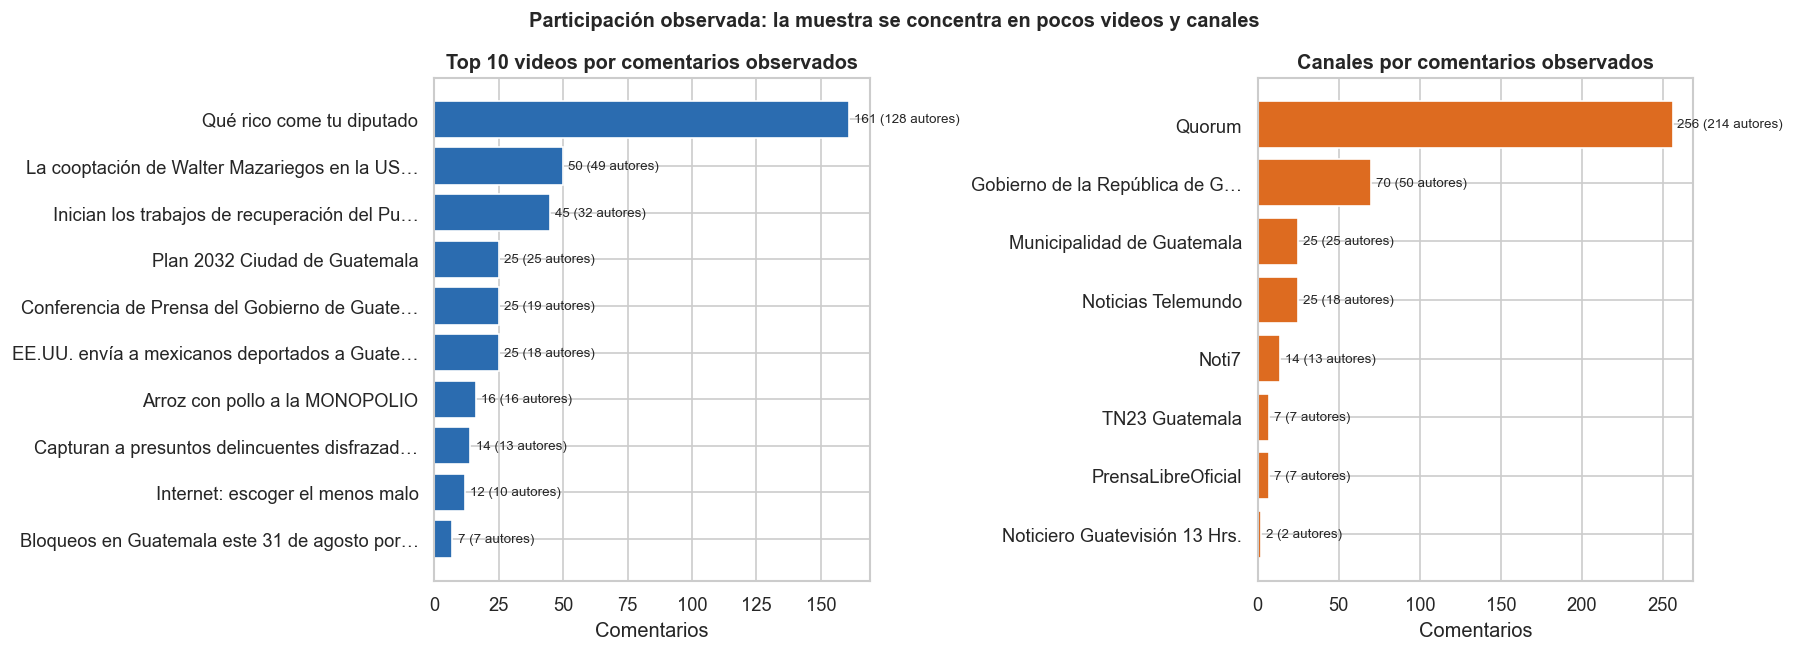

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
top_v = videos_eda.nlargest(10, "comentarios_obs").sort_values("comentarios_obs")
axes[0].barh([acortar(t, 44) for t in top_v["title"]], top_v["comentarios_obs"], color=AZUL)
axes[0].set(title="Top 10 videos por comentarios observados", xlabel="Comentarios")
for y, (c, a) in enumerate(zip(top_v["comentarios_obs"], top_v["autores_unicos"])):
    axes[0].text(c + 2, y, f"{c} ({a} autores)", va="center", fontsize=8)

top_c = por_canal.nlargest(8, "comentarios").sort_values("comentarios")
axes[1].barh([acortar(t, 30) for t in top_c["channel_name"]], top_c["comentarios"], color=NARANJA)
axes[1].set(title="Canales por comentarios observados", xlabel="Comentarios")
for y, (c, a) in enumerate(zip(top_c["comentarios"], top_c["autores"])):
    axes[1].text(c + 3, y, f"{c} ({a} autores)", va="center", fontsize=8)
fig.suptitle("Participación observada: la muestra se concentra en pocos videos y canales", fontweight="bold")
fig.tight_layout()
guardar_figura("01_top_participacion")

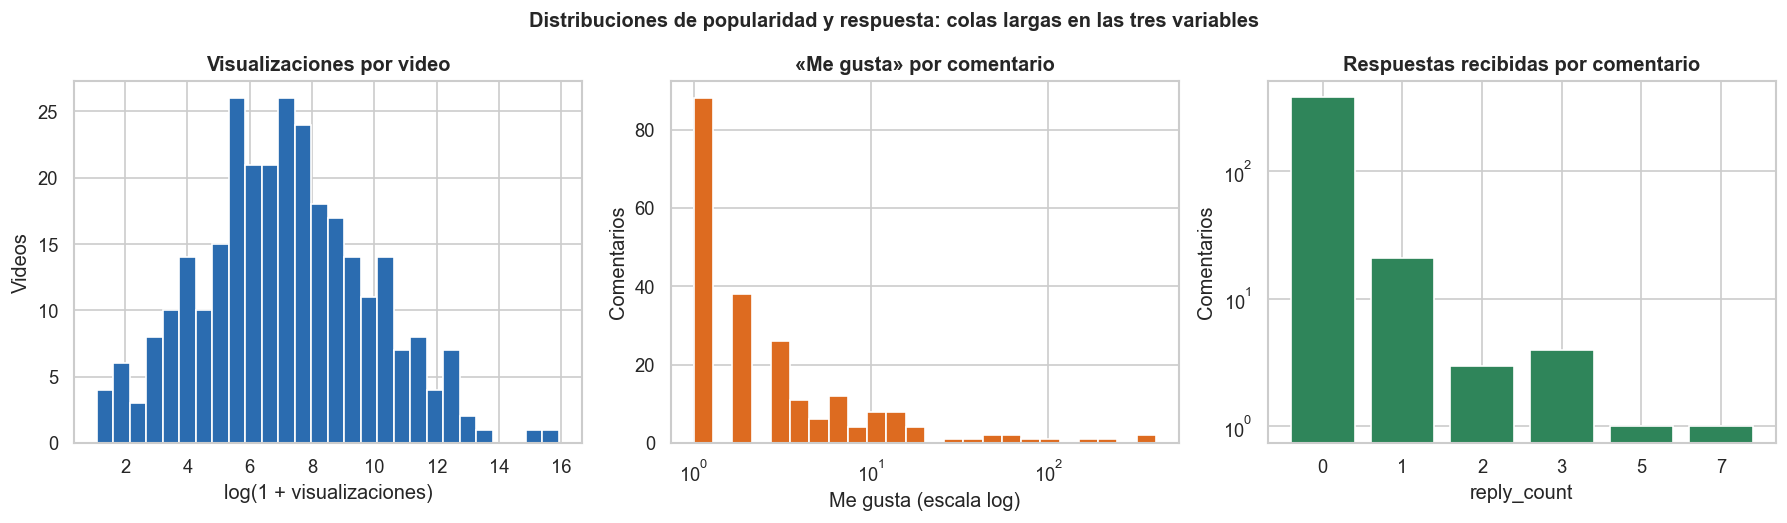

In [23]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.4))
axes[0].hist(np.log1p(videos_eda["view_count"].astype(float)), bins=28, color=AZUL, edgecolor="white")
axes[0].set(title="Visualizaciones por video", xlabel="log(1 + visualizaciones)", ylabel="Videos")
axes[1].hist(comentarios["like_count"], bins=np.logspace(0, np.log10(max(comentarios["like_count"].max(), 2)), 25),
             color=NARANJA, edgecolor="white")
axes[1].set(title="«Me gusta» por comentario", xlabel="Me gusta (escala log)", ylabel="Comentarios", xscale="log")
conteo_respuestas = comentarios["reply_count"].value_counts().sort_index()
axes[2].bar(conteo_respuestas.index.astype(str), conteo_respuestas.values, color=VERDE)
axes[2].set(title="Respuestas recibidas por comentario", xlabel="reply_count", ylabel="Comentarios")
axes[2].set_yscale("log")
fig.suptitle("Distribuciones de popularidad y respuesta: colas largas en las tres variables", fontweight="bold")
fig.tight_layout()
guardar_figura("02_distribuciones_conteos")

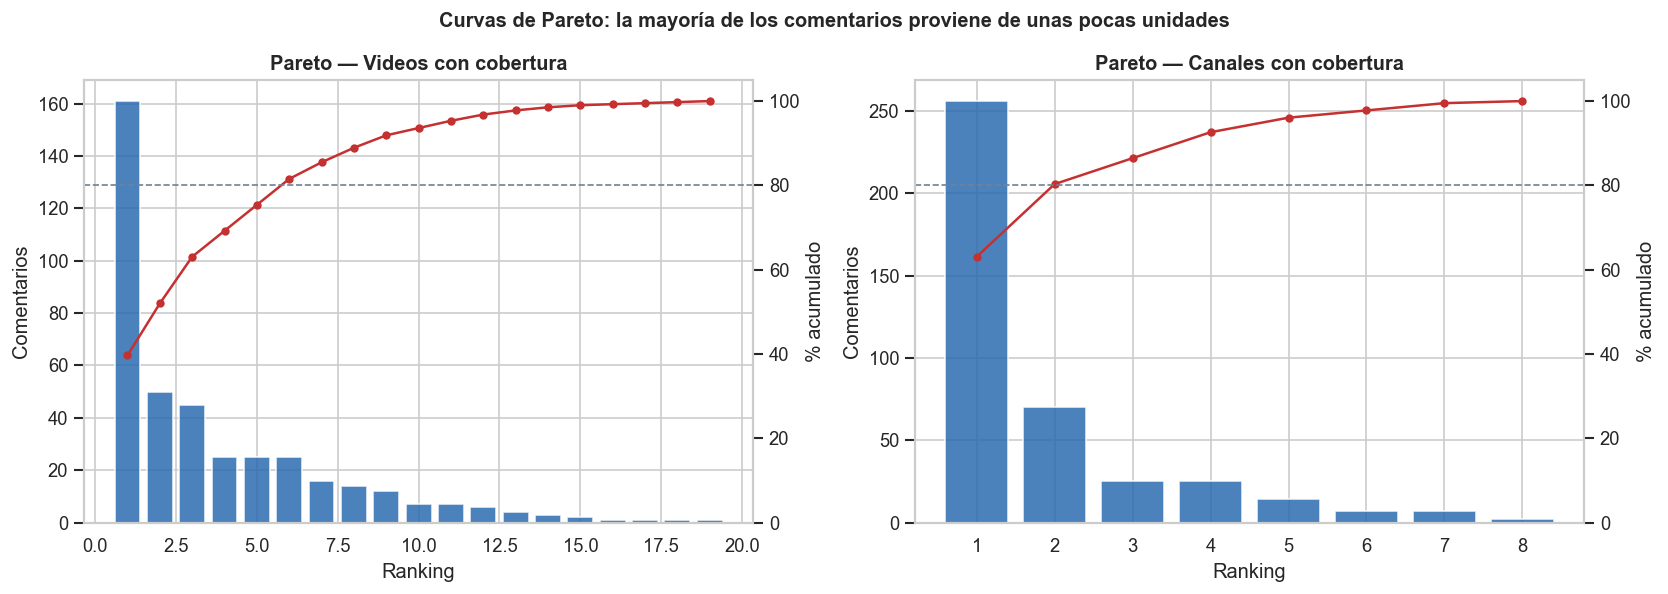

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for eje, valores, titulo in [
    (axes[0], por_video["comentarios_obs"].sort_values(ascending=False), "Videos con cobertura"),
    (axes[1], por_canal.query("comentarios > 0")["comentarios"].sort_values(ascending=False), "Canales con cobertura"),
]:
    acumulado = valores.cumsum() / valores.sum() * 100
    posiciones = np.arange(1, len(valores) + 1)
    eje.bar(posiciones, valores.values, color=AZUL, alpha=0.85, label="Comentarios")
    gemelo = eje.twinx()
    gemelo.plot(posiciones, acumulado.values, color=ROJO, marker="o", ms=4, label="Acumulado %")
    gemelo.axhline(80, color=GRIS, ls="--", lw=1)
    gemelo.set_ylim(0, 105)
    gemelo.set_ylabel("% acumulado")
    gemelo.grid(False)
    eje.set(title=f"Pareto — {titulo}", xlabel="Ranking", ylabel="Comentarios")
fig.suptitle("Curvas de Pareto: la mayoría de los comentarios proviene de unas pocas unidades", fontweight="bold")
fig.tight_layout()
guardar_figura("03_concentracion_pareto")

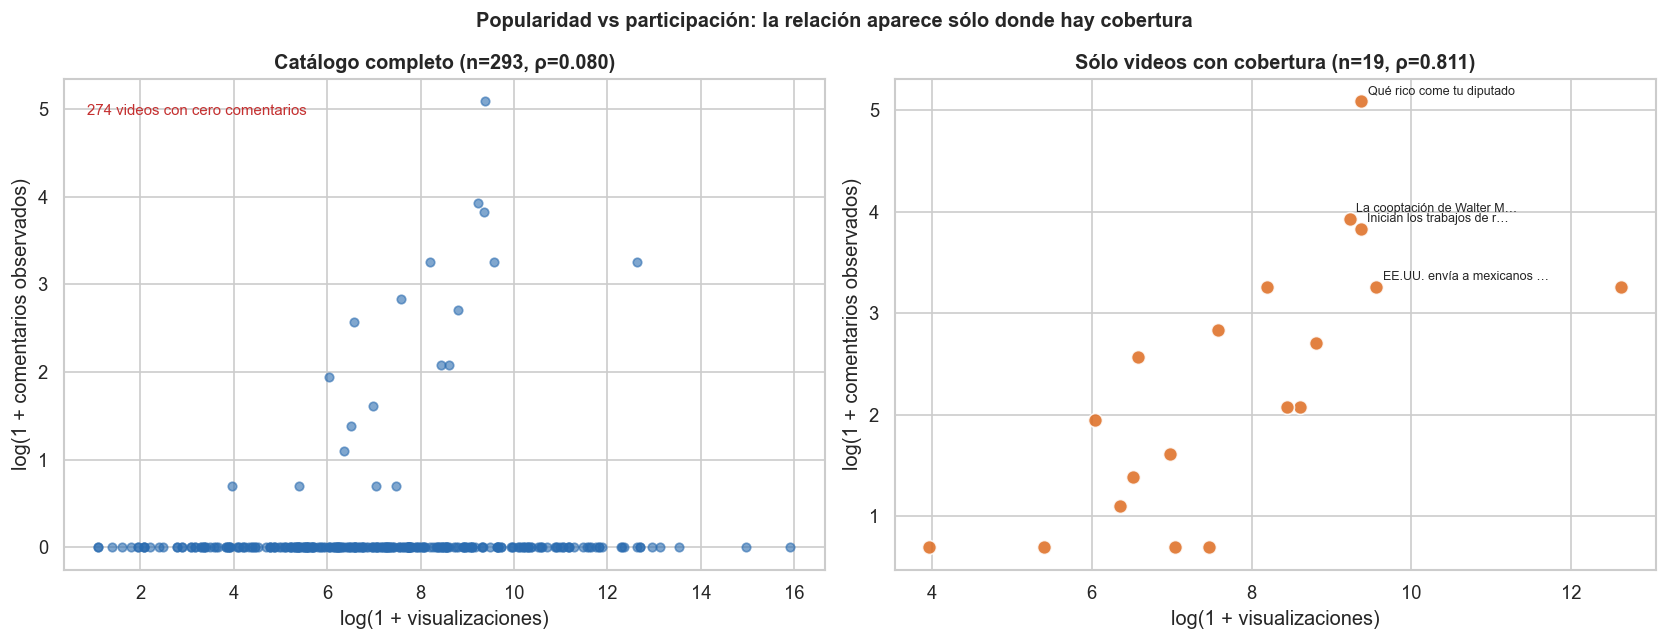

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.4))
axes[0].scatter(np.log1p(videos_eda["view_count"].astype(float)), np.log1p(videos_eda["comentarios_obs"]),
                color=AZUL, alpha=0.6, s=26)
axes[0].set(title=f"Catálogo completo (n={len(videos_eda)}, ρ={rho_todos:.3f})",
            xlabel="log(1 + visualizaciones)", ylabel="log(1 + comentarios observados)")
axes[0].text(0.03, 0.95, f"{int((videos_eda['comentarios_obs'] == 0).sum())} videos con cero comentarios",
             transform=axes[0].transAxes, va="top", fontsize=9, color=ROJO)
axes[1].scatter(np.log1p(sub["view_count"].astype(float)), np.log1p(sub["comentarios_obs"]),
                color=NARANJA, alpha=0.85, s=70, edgecolor="white")
axes[1].set(title=f"Sólo videos con cobertura (n={len(sub)}, ρ={rho_cob:.3f})",
            xlabel="log(1 + visualizaciones)", ylabel="log(1 + comentarios observados)")
for _, fila in sub.nlargest(4, "comentarios_obs").iterrows():
    axes[1].annotate(acortar(fila["title"], 26), (np.log1p(float(fila["view_count"])), np.log1p(fila["comentarios_obs"])),
                     fontsize=7.5, xytext=(4, 4), textcoords="offset points")
fig.suptitle("Popularidad vs participación: la relación aparece sólo donde hay cobertura", fontweight="bold")
fig.tight_layout()
guardar_figura("04_visualizaciones_vs_comentarios")

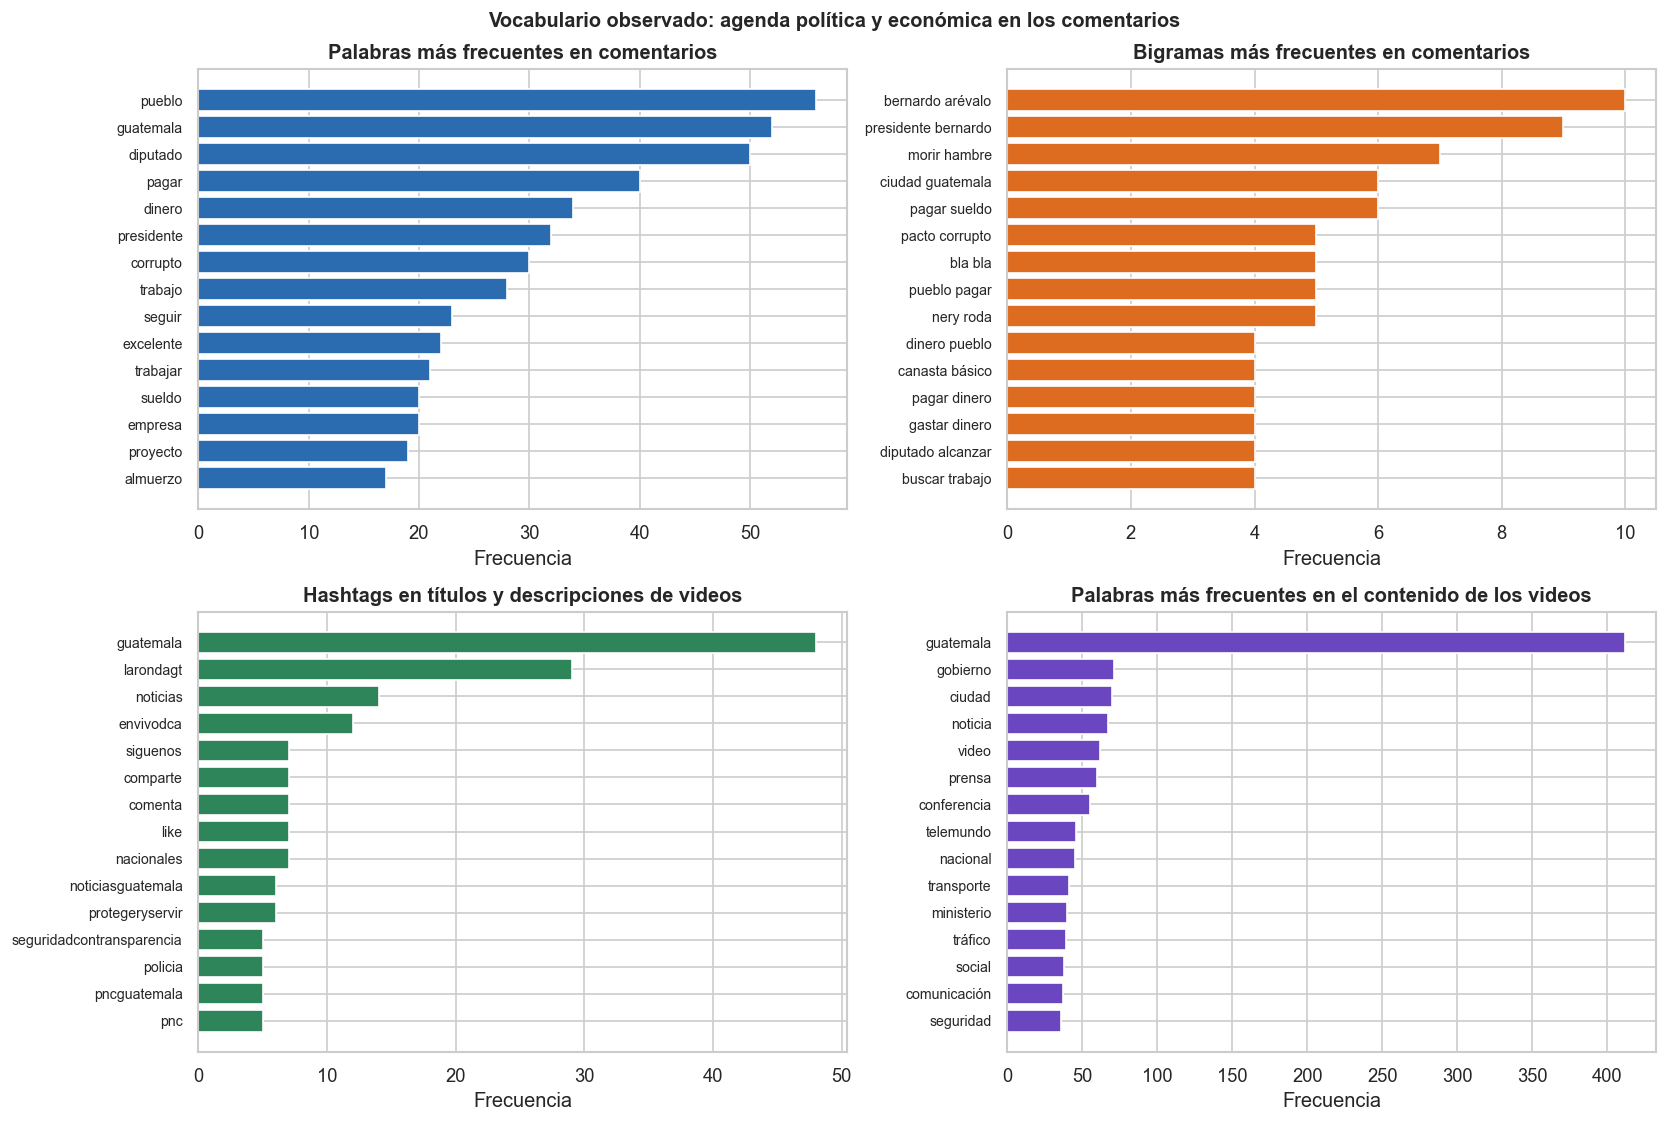

In [26]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
especificaciones = [
    (palabras_comentarios.head(15), "termino", "Palabras más frecuentes en comentarios", AZUL),
    (bigramas_comentarios.head(15), "bigrama", "Bigramas más frecuentes en comentarios", NARANJA),
    (hashtags_videos.head(15), "hashtag", "Hashtags en títulos y descripciones de videos", VERDE),
    (palabras_videos.head(15), "termino", "Palabras más frecuentes en el contenido de los videos", MORADO),
]
for eje, (frame, columna, titulo, color) in zip(axes.ravel(), especificaciones):
    datos = frame.sort_values("frecuencia")
    eje.barh(datos[columna], datos["frecuencia"], color=color)
    eje.set(title=titulo, xlabel="Frecuencia")
    eje.tick_params(axis="y", labelsize=8.5)
fig.suptitle("Vocabulario observado: agenda política y económica en los comentarios", fontweight="bold")
fig.tight_layout()
guardar_figura("05_frecuencias_texto")

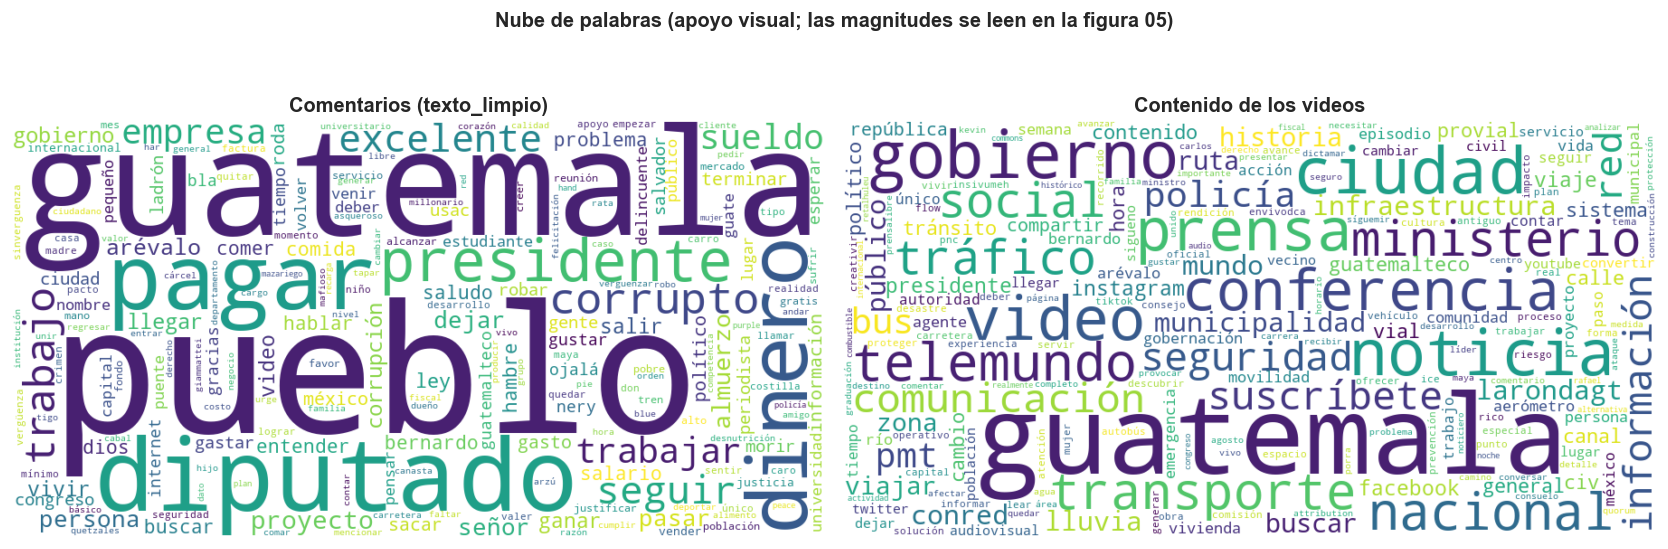

Nube de palabras generada.


In [27]:
try:
    from wordcloud import WordCloud
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    for eje, textos, titulo in [
        (axes[0], " ".join(comentarios["texto_limpio"]), "Comentarios (texto_limpio)"),
        (axes[1], " ".join(videos["texto_limpio"]), "Contenido de los videos"),
    ]:
        nube = WordCloud(width=900, height=460, background_color="white", colormap="viridis",
                         random_state=RANDOM_SEED, collocations=False).generate(textos)
        eje.imshow(nube, interpolation="bilinear")
        eje.set_title(titulo)
        eje.axis("off")
    fig.suptitle("Nube de palabras (apoyo visual; las magnitudes se leen en la figura 05)", fontweight="bold")
    fig.tight_layout()
    guardar_figura("06_nube_de_palabras")
    print("Nube de palabras generada.")
except ImportError:
    print("wordcloud no está instalado; se omite la nube (los gráficos de barras la sustituyen).")

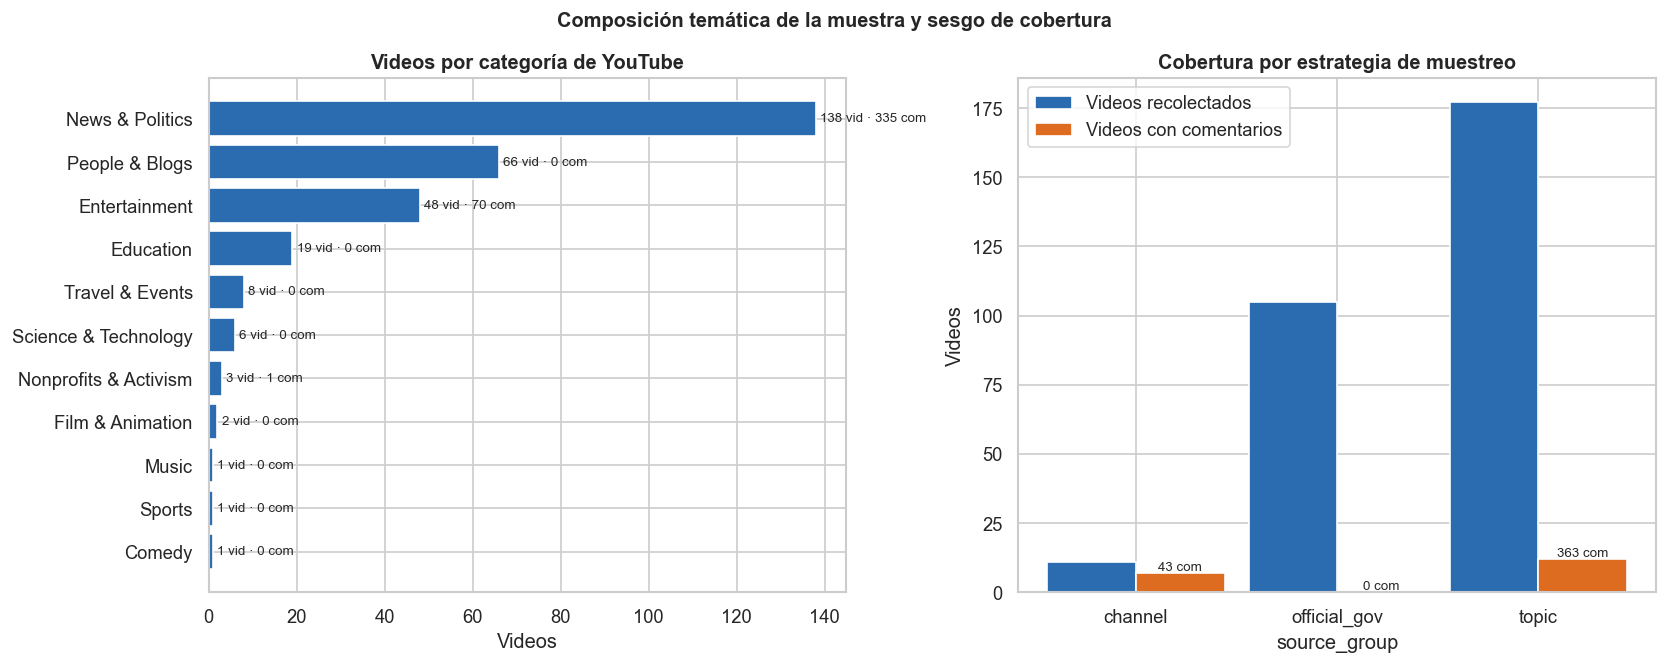

source_group  videos  comentarios  con_cobertura
     channel      11           43              7
official_gov     105            0              0
       topic     177          363             12


In [28]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.6))
categorias = videos_eda["category"].value_counts().sort_values()
axes[0].barh(categorias.index, categorias.values, color=AZUL)
axes[0].set(title="Videos por categoría de YouTube", xlabel="Videos")
comentarios_por_categoria = videos_eda.groupby("category")["comentarios_obs"].sum().reindex(categorias.index)
for y, (v, c) in enumerate(zip(categorias.values, comentarios_por_categoria.values)):
    axes[0].text(v + 1, y, f"{v} vid · {int(c)} com", va="center", fontsize=8)

resumen_fuente = videos_eda.groupby("source_group").agg(
    videos=("video_id", "size"), comentarios=("comentarios_obs", "sum"),
    con_cobertura=("tiene_comentarios", "sum")).reset_index()
x = np.arange(len(resumen_fuente))
axes[1].bar(x - 0.22, resumen_fuente["videos"], width=0.44, color=AZUL, label="Videos recolectados")
axes[1].bar(x + 0.22, resumen_fuente["con_cobertura"], width=0.44, color=NARANJA, label="Videos con comentarios")
axes[1].set(title="Cobertura por estrategia de muestreo", xticks=x, xlabel="source_group", ylabel="Videos")
axes[1].set_xticklabels(resumen_fuente["source_group"])
axes[1].legend()
for i, fila in resumen_fuente.iterrows():
    axes[1].text(i + 0.22, fila["con_cobertura"] + 1, f"{int(fila['comentarios'])} com", ha="center", fontsize=8)
fig.suptitle("Composición temática de la muestra y sesgo de cobertura", fontweight="bold")
fig.tight_layout()
guardar_figura("07_categorias_y_fuentes")
registrar("resumen_fuente", resumen_fuente.to_dict("records"))
print(resumen_fuente.to_string(index=False))

### 3.5 Preguntas obligatorias del inciso 3.5

Cada respuesta se sostiene con una tabla calculada a continuación. Las preguntas sobre comunidades
se amplían en la actividad 7 con la partición formal, y las de sentimiento en la actividad 9.

In [29]:
# (a) ¿Qué videos y canales concentran la mayor participación observada?
concentran_videos = videos_eda.nlargest(5, "comentarios_obs")[
    ["title", "channel_name", "category", "view_count", "comentarios_obs", "autores_unicos", "likes"]
].assign(cuota_pct=lambda d: (100 * d["comentarios_obs"] / len(comentarios)).round(1))
concentran_canales = por_canal.nlargest(5, "comentarios")[
    ["channel_name", "videos", "videos_con_comentarios", "comentarios", "autores"]
].assign(cuota_pct=lambda d: (100 * d["comentarios"] / len(comentarios)).round(1))
guardar_tabla(concentran_videos, "28_p1_videos_que_concentran")
guardar_tabla(concentran_canales, "29_p1_canales_que_concentran")
registrar("p1_videos", concentran_videos.to_dict("records"))
registrar("p1_canales", concentran_canales.to_dict("records"))
print(concentran_videos.to_string(index=False))
print()
print(concentran_canales.to_string(index=False))

                                                                                            title                          channel_name        category  view_count  comentarios_obs  autores_unicos  likes  cuota_pct
                                                                        Qué rico come tu diputado                                Quorum News & Politics       11775              161             128    358       39.7
                                                    La cooptación de Walter Mazariegos en la USAC                                Quorum News & Politics       10156               50              49     91       12.3
                                       Inician los trabajos de recuperación del Puente Belice II. Gobierno de la República de Guatemala   Entertainment       11670               45              32     90       11.1
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo                    Noticias Telemundo News

In [30]:
# (b) ¿Existen audiencias compartidas entre videos, canales o temas?
autores_multivideo = por_autor.query("videos > 1").sort_values(["canales", "videos", "comentarios"], ascending=False)
autores_multicanal = por_autor.query("canales > 1").sort_values(["canales", "comentarios"], ascending=False)

detalle_compartidos = (
    comentarios[comentarios["author_channel_id"].isin(autores_multivideo["author_channel_id"])]
    .groupby(["author_handle", "channel_name"])["video_id"].nunique()
    .reset_index(name="videos_comentados")
    .sort_values(["author_handle", "videos_comentados"], ascending=[True, False])
)
guardar_tabla(autores_multivideo, "30_p2_autores_en_varios_videos")
guardar_tabla(detalle_compartidos, "31_p2_detalle_audiencia_compartida")

audiencia = pd.DataFrame([
    ["Autores que comentan en más de un video", len(autores_multivideo), round(100 * len(autores_multivideo) / len(por_autor), 2)],
    ["Autores que comentan en más de un canal", len(autores_multicanal), round(100 * len(autores_multicanal) / len(por_autor), 2)],
    ["Autores exclusivos de un solo video", int((por_autor["videos"] == 1).sum()), round(100 * (por_autor["videos"] == 1).mean(), 2)],
], columns=["indicador", "autores", "porcentaje_del_total"])
guardar_tabla(audiencia, "32_p2_audiencia_compartida_resumen")
registrar("audiencia_compartida", audiencia.to_dict("records"))
registrar("autores_multivideo_n", len(autores_multivideo))
registrar("autores_multicanal_n", len(autores_multicanal))
print(audiencia.to_string(index=False))
print()
print(autores_multivideo.to_string(index=False))

                              indicador  autores  porcentaje_del_total
Autores que comentan en más de un video        9                  2.71
Autores que comentan en más de un canal        4                  1.20
    Autores exclusivos de un solo video      323                 97.29

       author_channel_id        author_handle  comentarios  videos  canales  likes  respuestas
UCHTGCgY2l-DQJIvlA_cpa_Q  @virgiliogarcia3039            3       2        2     14           0
UCdFlugHJJa4l3YqWuNRmvXw   @MarcosCarillo-b1r            2       2        2      0           1
UCjZgFEowMBrsjodqfovzdKw @franciscoflores3120            2       2        2      0           0
UCsUCN0Yq_UyTvKjOJLmNrnQ    @moisesvaldez4043            2       2        2      0           0
UCvcu1kR8xMYy_I1Ty-2mV2Q        @hashojea7348            4       3        1      0           0
UCpsKOkt5iWTbenzeuq7dsmQ       @inge_vergueta            3       3        1      4           0
UCylqlpsh8ENNM1LqgQ1KbxA         @Jel.Awesh.M     

In [31]:
# (c) ¿Qué autores funcionan como puentes entre contenidos que de otra forma permanecerían separados?
#     Evidencia preliminar: autores presentes en varios videos y, sobre todo, en varios canales.
puentes_preliminares = autores_multivideo.merge(
    comentarios.groupby("author_channel_id")["video_id"].apply(lambda s: " | ".join(sorted(set(s)))).rename("videos_ids"),
    on="author_channel_id", how="left",
).merge(
    comentarios.groupby("author_channel_id")["channel_name"].apply(lambda s: " | ".join(sorted(set(s)))).rename("canales"),
    on="author_channel_id", how="left",
)
guardar_tabla(puentes_preliminares, "33_p3_autores_puente_preliminares")
registrar("puentes_preliminares", puentes_preliminares.to_dict("records"))
puentes_preliminares[["author_handle", "comentarios", "videos", "canales_x", "canales_y"]].rename(
    columns={"canales_x": "n_canales", "canales_y": "canales"})

,author_handle,comentarios,videos,n_canales,canales
0,@virgiliogarcia3039,3,2,2,Gobierno de la República de Guatemala | Quorum
1,@MarcosCarillo-b1r,2,2,2,Quorum | TN23 Guatemala
2,@franciscoflores3120,2,2,2,Gobierno de la República de Guatemala | Noti7
3,@moisesvaldez4043,2,2,2,PrensaLibreOficial | Quorum
4,@hashojea7348,4,3,1,Quorum
5,@inge_vergueta,3,3,1,Quorum
6,@Jel.Awesh.M,3,2,1,Quorum
7,@Alejandro00710,2,2,1,Quorum
8,@josegil3813,2,2,1,Gobierno de la República de Guatemala


In [32]:
# (d) ¿Qué temas y sentimientos caracterizan la participación por video? (nivel comunidad: act. 7 y 9)
def terminos_de(video_id: str, n: int = 6) -> str:
    textos = comentarios.loc[comentarios["video_id"] == video_id, "texto_limpio"]
    contador = Counter(t for texto in textos for t in str(texto).split())
    return ", ".join(t for t, _ in contador.most_common(n))


perfil_videos = por_video.merge(
    videos[["video_id", "title", "channel_name", "category"]], on="video_id", how="left"
)
perfil_videos["terminos"] = perfil_videos["video_id"].map(terminos_de)
sentimiento_video = comentarios.groupby("video_id").agg(
    sent_medio=("puntaje_sentimiento", "mean"),
    pct_neg=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
    pct_pos=("sentimiento", lambda s: round(100 * (s == "POS").mean(), 1)),
).reset_index()
perfil_videos = perfil_videos.merge(sentimiento_video, on="video_id", how="left")
perfil_videos["sent_medio"] = perfil_videos["sent_medio"].round(3)
perfil_videos = perfil_videos.sort_values("comentarios_obs", ascending=False)
guardar_tabla(perfil_videos[["video_id", "title", "channel_name", "category", "comentarios_obs",
                             "autores_unicos", "sent_medio", "pct_neg", "pct_pos", "terminos"]],
              "34_p4_perfil_tematico_y_sentimiento_por_video")
registrar("perfil_videos", perfil_videos.head(8)[
    ["title", "channel_name", "comentarios_obs", "sent_medio", "pct_neg", "pct_pos", "terminos"]].to_dict("records"))
print(perfil_videos.head(8)[["title", "comentarios_obs", "sent_medio", "pct_neg", "terminos"]].to_string(index=False))

                                                                                            title  comentarios_obs  sent_medio  pct_neg                                                        terminos
                                                                        Qué rico come tu diputado              161      -0.671     80.7                pueblo, diputado, pagar, dinero, trabajo, sueldo
                                                    La cooptación de Walter Mazariegos en la USAC               50      -0.342     58.0 corrupto, usac, estudiante, universidad, excelente, información
                                       Inician los trabajos de recuperación del Puente Belice II.               45      -0.109     40.0    presidente, guatemala, proyecto, arévalo, terminar, bernardo
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo               25      -0.473     64.0                   you, deportar, entrar, méxico, persona, pasar


In [33]:
# (e) ¿La visibilidad medida por visualizaciones coincide con la participación observada?
ranking = sub.copy()
ranking["rank_vistas"] = ranking["view_count"].rank(ascending=False, method="min").astype(int)
ranking["rank_comentarios"] = ranking["comentarios_obs"].rank(ascending=False, method="min").astype(int)
ranking["desfase"] = ranking["rank_vistas"] - ranking["rank_comentarios"]
ranking["comentarios_por_10k_vistas"] = (
    10_000 * ranking["comentarios_obs"] / ranking["view_count"].astype(float)).round(2)
ranking = ranking.sort_values("rank_comentarios")
guardar_tabla(ranking[["title", "channel_name", "view_count", "comentarios_obs",
                       "rank_vistas", "rank_comentarios", "desfase", "comentarios_por_10k_vistas"]],
              "35_p5_visibilidad_vs_participacion")
registrar("ranking_visibilidad", ranking.head(10)[
    ["title", "view_count", "comentarios_obs", "rank_vistas", "rank_comentarios", "comentarios_por_10k_vistas"]
].to_dict("records"))
registrar("desfase_max", int(ranking["desfase"].abs().max()))
print(ranking[["title", "view_count", "comentarios_obs", "rank_vistas", "rank_comentarios",
               "comentarios_por_10k_vistas"]].head(10).to_string(index=False))

                                                                                            title  view_count  comentarios_obs  rank_vistas  rank_comentarios  comentarios_por_10k_vistas
                                                                        Qué rico come tu diputado       11775              161            3                 1                      136.73
                                                    La cooptación de Walter Mazariegos en la USAC       10156               50            5                 2                       49.23
                                       Inician los trabajos de recuperación del Puente Belice II.       11670               45            4                 3                       38.56
EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticias Telemundo       14200               25            2                 4                       17.61
                                      Conferencia de Prensa del Gobier

In [34]:
# (f) ¿Qué conclusiones están limitadas por el procedimiento de recolección y la cobertura?
cobertura_por_fuente = videos_eda.groupby("source_group").agg(
    videos=("video_id", "size"),
    con_comentarios=("tiene_comentarios", "sum"),
    comentarios=("comentarios_obs", "sum"),
    vistas_medianas=("view_count", "median"),
).reset_index()
cobertura_por_fuente["cobertura_pct"] = (
    100 * cobertura_por_fuente["con_comentarios"] / cobertura_por_fuente["videos"]).round(1)
guardar_tabla(cobertura_por_fuente, "36_p6_cobertura_por_estrategia")
registrar("cobertura_por_fuente", cobertura_por_fuente.to_dict("records"))
print(cobertura_por_fuente.to_string(index=False))

source_group  videos  con_comentarios  comentarios  vistas_medianas  cobertura_pct
     channel      11                7           43            673.0           63.6
official_gov     105                0            0            521.0            0.0
       topic     177               12          363           2214.0            6.8


### 3.6 Tres preguntas adicionales surgidas del análisis exploratorio

1. ¿La intensidad de participación de un autor (varios comentarios en el mismo video) se comporta
   distinto de su amplitud (comentar en varios videos)?
2. ¿Los comentarios con más «me gusta» son sistemáticamente más negativos que el resto?
3. ¿La estrategia de muestreo (`source_group`) produce perfiles temáticos y de sentimiento distintos?

In [35]:
# Pregunta adicional 1: intensidad vs amplitud.
por_autor_ext = por_autor.merge(
    comentarios.groupby("author_channel_id")["puntaje_sentimiento"].mean().rename("sent_medio"),
    on="author_channel_id", how="left")
por_autor_ext["comentarios_por_video"] = (por_autor_ext["comentarios"] / por_autor_ext["videos"]).round(2)

intensidad = pd.DataFrame([
    ["Autores con 1 comentario en 1 video", int(((por_autor_ext["comentarios"] == 1) & (por_autor_ext["videos"] == 1)).sum())],
    ["Autores con varios comentarios en un solo video (intensidad)",
     int(((por_autor_ext["comentarios"] > 1) & (por_autor_ext["videos"] == 1)).sum())],
    ["Autores presentes en varios videos (amplitud)", int((por_autor_ext["videos"] > 1).sum())],
    ["Máximo de comentarios de un autor en un mismo video",
     int(comentarios.groupby(["author_channel_id", "video_id"]).size().max())],
], columns=["perfil", "autores"])
rho_int, p_int = spearman(por_autor_ext["comentarios"], por_autor_ext["videos"])
guardar_tabla(intensidad, "37_extra1_intensidad_vs_amplitud")
registrar("intensidad", intensidad.to_dict("records"))
registrar("rho_intensidad_amplitud", round(rho_int, 3))
print(intensidad.to_string(index=False))
print(f"\nSpearman entre número de comentarios y número de videos por autor: ρ={rho_int:.3f} (p={p_int:.4f})")

                                                      perfil  autores
                         Autores con 1 comentario en 1 video      286
Autores con varios comentarios en un solo video (intensidad)       37
               Autores presentes en varios videos (amplitud)        9
         Máximo de comentarios de un autor en un mismo video        6

Spearman entre número de comentarios y número de videos por autor: ρ=0.420 (p=0.0000)


In [36]:
# Pregunta adicional 2: ¿los comentarios más aplaudidos son más negativos?
comentarios["tramo_likes"] = pd.cut(
    comentarios["like_count"], bins=[-1, 0, 2, 10, 50, np.inf],
    labels=["0", "1–2", "3–10", "11–50", ">50"])
likes_sentimiento = comentarios.groupby("tramo_likes", observed=True).agg(
    comentarios_n=("comment_id", "size"),
    sent_medio=("puntaje_sentimiento", "mean"),
    pct_negativos=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
    likes_medianos=("like_count", "median"),
).reset_index()
likes_sentimiento["sent_medio"] = likes_sentimiento["sent_medio"].round(3)
rho_ls, p_ls = spearman(comentarios["like_count"], comentarios["puntaje_sentimiento"])
guardar_tabla(likes_sentimiento, "38_extra2_likes_vs_sentimiento")
registrar("likes_sentimiento", likes_sentimiento.to_dict("records"))
registrar("rho_likes_sentimiento", round(rho_ls, 3))
registrar("p_likes_sentimiento", round(p_ls, 4))
print(likes_sentimiento.to_string(index=False))
print(f"\nSpearman entre «me gusta» y puntaje de sentimiento: ρ={rho_ls:.3f} (p={p_ls:.4f})")

tramo_likes  comentarios_n  sent_medio  pct_negativos  likes_medianos
          0            189      -0.529           69.8             0.0
        1–2            126      -0.348           57.1             1.0
       3–10             63      -0.241           57.1             4.0
      11–50             19      -0.070           47.4            15.0
        >50              9       0.729            0.0           113.0

Spearman entre «me gusta» y puntaje de sentimiento: ρ=0.234 (p=0.0000)


In [37]:
# Pregunta adicional 3: ¿la estrategia de muestreo produce perfiles distintos?
perfil_fuente = comentarios.groupby("source_group").agg(
    comentarios_n=("comment_id", "size"),
    autores=("author_channel_id", "nunique"),
    videos=("video_id", "nunique"),
    likes_medianos=("like_count", "median"),
    sent_medio=("puntaje_sentimiento", "mean"),
    pct_negativos=("sentimiento", lambda s: round(100 * (s == "NEG").mean(), 1)),
).reset_index()
perfil_fuente["sent_medio"] = perfil_fuente["sent_medio"].round(3)
perfil_fuente["terminos"] = perfil_fuente["source_group"].map(
    lambda g: ", ".join(t for t, _ in Counter(
        t for texto in comentarios.loc[comentarios["source_group"] == g, "texto_limpio"]
        for t in str(texto).split()).most_common(6)))
guardar_tabla(perfil_fuente, "39_extra3_perfil_por_estrategia")
registrar("perfil_fuente", perfil_fuente.to_dict("records"))
print(perfil_fuente.to_string(index=False))

source_group  comentarios_n  autores  videos  likes_medianos  sent_medio  pct_negativos                                                   terminos
     channel            231      192      11             1.0      -0.543           71.9           pueblo, diputado, pagar, dinero, trabajo, sueldo
       topic            175      144       9             1.0      -0.162           47.4 guatemala, presidente, proyecto, arévalo, gobierno, saludo


## 4. Construcción de la red bipartita autor–video

### 4.5 Qué significa exactamente una arista (se declara antes de construirla)

Una arista **no dirigida** `autor — video` significa **una sola cosa**: *ese autor publicó al menos
un comentario principal en ese video dentro de la muestra recolectada*. Su **peso** es el número de
comentarios que ese autor publicó en ese video.

Una arista **no** significa:

- que el autor sea amigo, seguidor o suscriptor del canal;
- que exista conversación directa con nadie (los datos no dicen quién respondió a quién);
- aprobación del contenido: la actividad 9 muestra que la mayoría de los comentarios son negativos,
  de modo que participar suele ser sinónimo de criticar, no de apoyar;
- que el autor haya visto el video completo, ni que sea su única actividad en YouTube.

La red es **bipartita**: sólo existen aristas autor↔video. Nunca autor↔autor ni video↔video; esas
relaciones aparecen únicamente como *proyecciones* (actividad 5), que son construcciones derivadas.

### 4.1 – 4.3 Tabla de nodos, tabla de aristas y construcción del grafo

In [38]:
def valor_grafo(valor):
    """Convierte a tipos que GraphML admite."""
    if isinstance(valor, (list, tuple, set, dict)):
        return json.dumps(list(valor), ensure_ascii=False)
    try:
        if valor is None or bool(pd.isna(valor)):
            return ""
    except (TypeError, ValueError):
        pass
    if isinstance(valor, (np.integer,)):
        return int(valor)
    if isinstance(valor, (np.floating,)):
        return float(valor)
    if isinstance(valor, (np.bool_,)):
        return bool(valor)
    return valor


# --- Tabla de aristas: una fila por par (autor, video) observado ---
aristas = comentarios.groupby(["author_channel_id", "video_id"]).agg(
    peso=("comment_id", "size"),
    likes=("like_count", "sum"),
    respuestas=("reply_count", "sum"),
    sent_medio=("puntaje_sentimiento", "mean"),
).reset_index()
aristas["sent_medio"] = aristas["sent_medio"].round(3)
aristas["origen"] = "author::" + aristas["author_channel_id"]
aristas["destino"] = "video::" + aristas["video_id"]
aristas["tipo_arista"] = "comento_en"
aristas = aristas.merge(comentarios[["author_channel_id", "author_handle"]].drop_duplicates(),
                        on="author_channel_id", how="left")
aristas = aristas.merge(videos[["video_id", "title", "channel_name"]], on="video_id", how="left")

# --- Tabla de nodos: autores + TODOS los videos del catálogo ---
nodos_autor = por_autor.rename(columns={"comentarios": "comentarios_publicados",
                                        "videos": "videos_comentados",
                                        "canales": "canales_comentados"}).copy()
nodos_autor = nodos_autor.merge(
    comentarios.groupby("author_channel_id")["puntaje_sentimiento"].mean().round(3).rename("sent_medio"),
    on="author_channel_id", how="left")
nodos_autor["node_id"] = "author::" + nodos_autor["author_channel_id"]
nodos_autor["tipo_nodo"] = "autor"
nodos_autor["bipartite"] = 0
nodos_autor["etiqueta"] = nodos_autor["author_handle"]
nodos_autor["id_original"] = nodos_autor["author_channel_id"]

nodos_video = videos_eda.rename(columns={"comentarios_obs": "comentarios_recibidos",
                                         "autores_unicos": "autores_distintos"}).copy()
nodos_video = nodos_video.merge(sentimiento_video[["video_id", "sent_medio"]], on="video_id", how="left")
nodos_video["node_id"] = "video::" + nodos_video["video_id"]
nodos_video["tipo_nodo"] = "video"
nodos_video["bipartite"] = 1
nodos_video["etiqueta"] = nodos_video["title"].map(lambda t: acortar(t, 60))
nodos_video["id_original"] = nodos_video["video_id"]

COLS_NODO = ["node_id", "tipo_nodo", "bipartite", "etiqueta", "id_original"]
nodos = pd.concat([
    nodos_autor[COLS_NODO + ["comentarios_publicados", "videos_comentados", "canales_comentados",
                             "likes", "respuestas", "sent_medio"]],
    nodos_video[COLS_NODO + ["channel_id", "channel_name", "category", "source_group", "view_count",
                             "comentarios_recibidos", "autores_distintos", "sent_medio", "tiene_comentarios"]],
], ignore_index=True)
nodos["observado"] = np.where(
    nodos["tipo_nodo"] == "autor", True, nodos["tiene_comentarios"].fillna(False)).astype(bool)

guardar_tabla(nodos, "40_nodos_red_bipartita")
guardar_tabla(aristas[["origen", "destino", "peso", "likes", "respuestas", "sent_medio", "tipo_arista",
                       "author_channel_id", "author_handle", "video_id", "title", "channel_name"]],
              "41_aristas_red_bipartita")
print(f"Nodos: {len(nodos)} (autores: {(nodos['tipo_nodo'] == 'autor').sum()}, videos: {(nodos['tipo_nodo'] == 'video').sum()})")
print(f"Aristas: {len(aristas)} — peso total: {int(aristas['peso'].sum())} (= total de comentarios)")
nodos.head(4)

Nodos: 625 (autores: 332, videos: 293)
Aristas: 343 — peso total: 406 (= total de comentarios)


,node_id,tipo_nodo,bipartite,etiqueta,id_original,comentarios_publicados,videos_comentados,canales_comentados,likes,respuestas,sent_medio,channel_id,channel_name,category,source_group,view_count,comentarios_recibidos,autores_distintos,tiene_comentarios,observado
0,author::UC-HeUTT6_g-VoiWds2a4H-w,autor,0,@JorgeMunoz-gd9et,UC-HeUTT6_g-VoiWds2a4H-w,1,1.0,1.0,0.0,0.0,0.449,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,True
1,author::UC-Iul5tDYH_oiAMXQH-KaaQ,autor,0,@AlbertoMancilla-p9h,UC-Iul5tDYH_oiAMXQH-KaaQ,1,1.0,1.0,1.0,0.0,0.920,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,True
2,author::UC-QOpE7GOxlXcHZ8b7HbQKA,autor,0,@mariaalexander427,UC-QOpE7GOxlXcHZ8b7HbQKA,2,1.0,1.0,0.0,0.0,-0.742,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,True
3,author::UC-fiZBS5Gp1eCJd9ucgWnCg,autor,0,@Tommii.10,UC-fiZBS5Gp1eCJd9ucgWnCg,1,1.0,1.0,6.0,0.0,-0.476,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,True


In [39]:
aristas[["origen", "destino", "peso", "likes", "respuestas", "sent_medio", "author_handle", "title"]].head(6)

,origen,destino,peso,likes,respuestas,sent_medio,author_handle,title
0,author::UC-HeUTT6_g-VoiWds2a4H-w,video::6W4u8sGEnGM,1,0,0,0.449,@JorgeMunoz-gd9et,Inician los trabajos de recuperación del Puente Belice II.
1,author::UC-Iul5tDYH_oiAMXQH-KaaQ,video::6W4u8sGEnGM,1,1,0,0.920,@AlbertoMancilla-p9h,Inician los trabajos de recuperación del Puente Belice II.
2,author::UC-QOpE7GOxlXcHZ8b7HbQKA,video::OkXlHx0hx-8,2,0,0,-0.742,@mariaalexander427,EE.UU. envía a mexicanos deportados a Guatemala antes de su regreso a México | Noticia...
3,author::UC-fiZBS5Gp1eCJd9ucgWnCg,video::j43HgwYFKfk,1,6,0,-0.476,@Tommii.10,La cooptación de Walter Mazariegos en la USAC
4,author::UC-hfX8J5JPJ-dfuakzegMLA,video::n8iP75gIpmw,1,6,0,0.574,@normaleticiaorozcojuarez2418,Qué rico come tu diputado
5,author::UC-jS_kA9w-OmpupXDx156Rg,video::n8iP75gIpmw,1,2,0,-0.963,@simoncreyesc7579,Qué rico come tu diputado


In [40]:
# --- Grafo completo (incluye los 274 videos sin comentarios recolectados) ---
G_completo = nx.Graph()
for _, fila in nodos.iterrows():
    atributos = {k: valor_grafo(v) for k, v in fila.items() if k != "node_id"}
    G_completo.add_node(fila["node_id"], **atributos)
for _, fila in aristas.iterrows():
    G_completo.add_edge(fila["origen"], fila["destino"], weight=int(fila["peso"]),
                        likes=int(fila["likes"]), respuestas=int(fila["respuestas"]),
                        sent_medio=float(fila["sent_medio"]), tipo="comento_en")

# --- Subgrafo observado: sólo nodos con al menos una arista ---
G_obs = G_completo.subgraph([n for n, g in G_completo.degree() if g > 0]).copy()

AUTORES_G = {n for n, d in G_completo.nodes(data=True) if d["tipo_nodo"] == "autor"}
VIDEOS_G = {n for n, d in G_completo.nodes(data=True) if d["tipo_nodo"] == "video"}
AUTORES_OBS = [n for n in G_obs if G_obs.nodes[n]["tipo_nodo"] == "autor"]
VIDEOS_OBS = [n for n in G_obs if G_obs.nodes[n]["tipo_nodo"] == "video"]

validacion = pd.DataFrame([
    ["¿Es bipartita?", nx.is_bipartite(G_completo)],
    ["Aristas dentro del mismo tipo (deben ser 0)",
     sum(1 for u, v in G_completo.edges() if G_completo.nodes[u]["tipo_nodo"] == G_completo.nodes[v]["tipo_nodo"])],
    ["Suma de pesos = número de comentarios",
     int(sum(d["weight"] for _, _, d in G_completo.edges(data=True))) == len(comentarios)],
    ["Nodos totales (red completa)", G_completo.number_of_nodes()],
    ["Aristas totales", G_completo.number_of_edges()],
    ["Nodos en la subred observada", G_obs.number_of_nodes()],
    ["Videos sin ninguna arista (falta de cobertura)", len(VIDEOS_G) - len(VIDEOS_OBS)],
], columns=["verificación", "resultado"])
guardar_tabla(validacion.astype(str), "42_validacion_red_bipartita")
registrar("red_nodos_total", G_completo.number_of_nodes())
registrar("red_aristas_total", G_completo.number_of_edges())
registrar("red_obs_nodos", G_obs.number_of_nodes())
registrar("red_obs_autores", len(AUTORES_OBS))
registrar("red_obs_videos", len(VIDEOS_OBS))
registrar("peso_total", int(aristas["peso"].sum()))
registrar("peso_max", int(aristas["peso"].max()))
validacion

,verificación,resultado
0,¿Es bipartita?,True
1,Aristas dentro del mismo tipo (deben ser 0),0
2,Suma de pesos = número de comentarios,True
3,Nodos totales (red completa),625
4,Aristas totales,343
5,Nodos en la subred observada,351
6,Videos sin ninguna arista (falta de cobertura),274


In [41]:
nx.write_graphml(G_completo, GRAFOS / "red_bipartita_autor_video.graphml")
nx.write_graphml(G_obs, GRAFOS / "red_bipartita_observada.graphml")
print("GraphML exportado para inspección en Gephi.")

GraphML exportado para inspección en Gephi.


### 4.4 Visualización de la red completa

Se visualiza **la red completa, sin eliminar nodos**: los 274 videos sin comentarios recolectados
son un hallazgo sustantivo (el sesgo de cobertura) y borrarlos por estética ocultaría el resultado
más importante del muestreo. Se usan dos vistas complementarias porque una sola no basta: un
diseño bipartito en columnas que muestra la escala real, y un diseño de fuerzas sobre la subred
observada que revela la estructura interna.

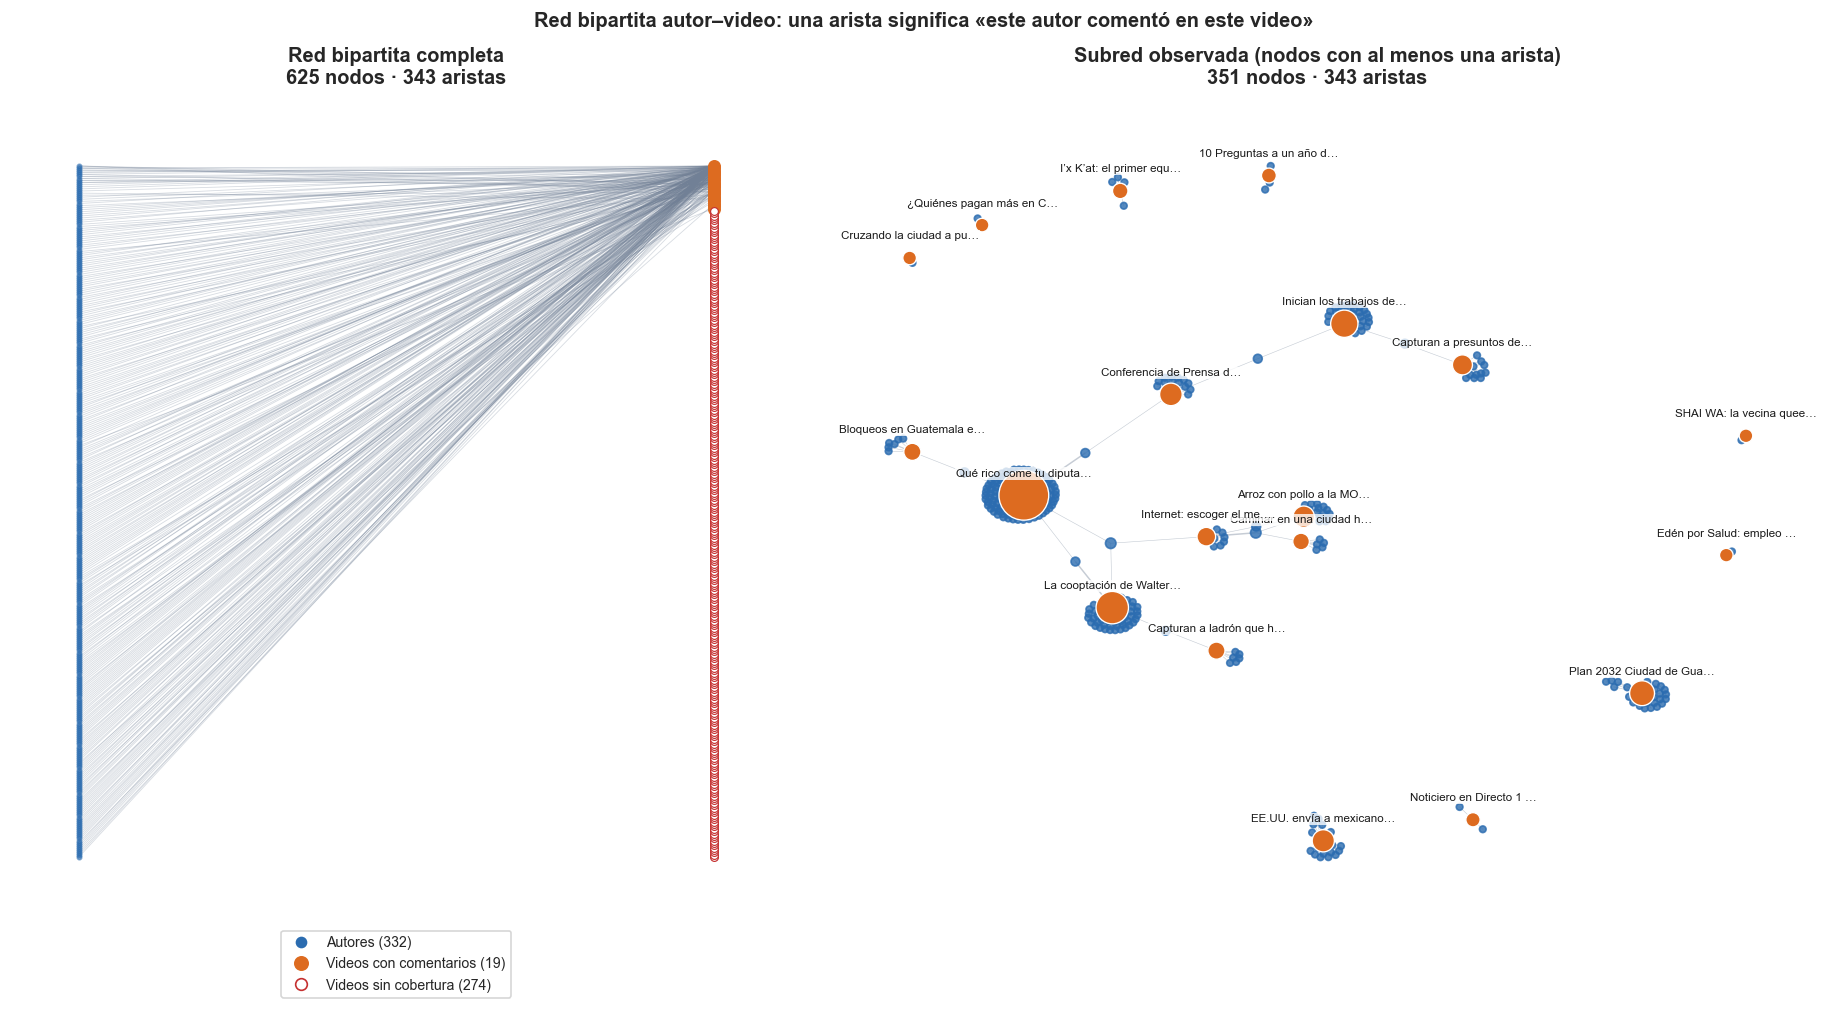

Figura 08 generada.


In [42]:
fig, ejes = plt.subplots(1, 2, figsize=(15.5, 8.5), gridspec_kw={"width_ratios": [1, 1.35]})

# Vista A: las dos particiones en columnas, incluyendo los videos sin cobertura.
autores_ordenados = sorted(AUTORES_G, key=lambda n: (G_completo.degree(n), n), reverse=True)
videos_ordenados = sorted(VIDEOS_G, key=lambda n: (G_completo.degree(n), n), reverse=True)
posicion = {}
posicion.update({n: (0.0, 1 - i / max(len(autores_ordenados) - 1, 1)) for i, n in enumerate(autores_ordenados)})
posicion.update({n: (1.0, 1 - i / max(len(videos_ordenados) - 1, 1)) for i, n in enumerate(videos_ordenados)})
videos_aislados = sorted(n for n in VIDEOS_G if G_completo.degree(n) == 0)

nx.draw_networkx_edges(G_completo, posicion, ax=ejes[0], edge_color=GRIS, alpha=0.28, width=0.5)
nx.draw_networkx_nodes(G_completo, posicion, nodelist=autores_ordenados, ax=ejes[0],
                       node_color=AZUL, node_size=7, alpha=0.55)
nx.draw_networkx_nodes(G_completo, posicion, nodelist=[n for n in videos_ordenados if G_completo.degree(n) > 0],
                       ax=ejes[0], node_color=NARANJA, node_size=46)
nx.draw_networkx_nodes(G_completo, posicion, nodelist=videos_aislados, ax=ejes[0],
                       node_color="white", edgecolors=ROJO, linewidths=0.7, node_size=22)
ejes[0].set_title(f"Red bipartita completa\n{G_completo.number_of_nodes()} nodos · {G_completo.number_of_edges()} aristas")
ejes[0].axis("off")
ejes[0].legend(handles=[
    Line2D([], [], marker="o", ls="", color=AZUL, ms=6, label=f"Autores ({len(AUTORES_G)})"),
    Line2D([], [], marker="o", ls="", color=NARANJA, ms=8, label=f"Videos con comentarios ({len(VIDEOS_OBS)})"),
    Line2D([], [], marker="o", ls="", mfc="white", mec=ROJO, ms=7, label=f"Videos sin cobertura ({len(videos_aislados)})"),
], loc="lower center", frameon=True, fontsize=8.5, bbox_to_anchor=(0.5, -0.09))

# Vista B: subred observada con diseño de fuerzas.
pos_obs = nx.spring_layout(G_obs, seed=RANDOM_SEED, k=0.30, iterations=400, weight="weight")
tam_video = [60 + 6.5 * G_obs.degree(n) for n in VIDEOS_OBS]
pesos = [G_obs[u][v]["weight"] for u, v in G_obs.edges()]
nx.draw_networkx_edges(G_obs, pos_obs, ax=ejes[1], edge_color=GRIS, alpha=0.4,
                       width=[0.35 + 0.55 * (w - 1) for w in pesos])
nx.draw_networkx_nodes(G_obs, pos_obs, nodelist=AUTORES_OBS, ax=ejes[1], node_color=AZUL,
                       node_size=[16 + 12 * (G_obs.degree(n) - 1) for n in AUTORES_OBS], alpha=0.8)
nx.draw_networkx_nodes(G_obs, pos_obs, nodelist=VIDEOS_OBS, ax=ejes[1], node_color=NARANJA,
                       node_size=tam_video, edgecolors="white", linewidths=0.8)
etiquetas_desplazadas = {n: (x, y + 0.055) for n, (x, y) in pos_obs.items() if n in VIDEOS_OBS}
textos = nx.draw_networkx_labels(
    G_obs, etiquetas_desplazadas, ax=ejes[1], font_size=7.0,
    labels={n: acortar(G_obs.nodes[n]["etiqueta"], 24) for n in VIDEOS_OBS})
for texto in textos.values():
    texto.set_bbox(dict(facecolor="white", edgecolor="none", alpha=0.78, pad=0.6))
ejes[1].set_title(f"Subred observada (nodos con al menos una arista)\n"
                  f"{G_obs.number_of_nodes()} nodos · {G_obs.number_of_edges()} aristas")
ejes[1].axis("off")
fig.suptitle("Red bipartita autor–video: una arista significa «este autor comentó en este video»",
             fontweight="bold", y=0.98)
fig.tight_layout()
guardar_figura("08_red_bipartita")
print("Figura 08 generada.")

## Cierre del hito 2

La participación observada está fuertemente concentrada en pocos videos y canales, y la cobertura
de comentarios condiciona todas las comparaciones. Popularidad y participación describen fenómenos
distintos: la correlación entre visualizaciones y comentarios sólo aparece al restringirse a los
videos con cobertura.

La red bipartita queda construida y validada, con la tabla de nodos, la tabla de aristas y el
significado exacto de una arista declarado antes de interpretarla. Las proyecciones, la topología,
las comunidades, la centralidad y el sentimiento se desarrollan en
`03_laboratorio6_completo.ipynb`.